# Notebook 2 : Multimodal Data Mining and Warehouse Insights
## Predicting Consumption Patterns of Indian Fashion E-Commerce Customers

**Student:** Chaitanya Kashyap(B240006AI) and Aditya(B240030CS) | **Course:** Data Warehousing & Mining | **Date:** 28 April 2026

---

This notebook picks up where the ETL notebook left off. The `mart_multimodal_customers` table built in Notebook 1 is loaded here and used for the full analytical pipeline. The dataset covers customer sessions from an Indian fashion retailer and the goal is to predict whether a customer falls into the Low, Medium, or High spending class.

**What this notebook covers:**
1. Exploratory Data Analysis — class distribution, correlations, and outlier checks
2. OLAP-style analysis — payment methods, device types, marketing channels, and festival impact
3. Time-series trend analysis and seasonal decomposition
4. Anomaly detection using Isolation Forest
5. ROLLUP simulation and cohort retention analysis
6. Customer segmentation using K-Means, GMM, Hierarchical Clustering, and DBSCAN
7. Churn prediction and Customer Lifetime Value (CLV) estimation
8. Association Rule Mining using FP-Growth vs Apriori
9. Multi-algorithm classification (Logistic Regression, Random Forest, XGBoost, LightGBM) with SMOTE
10. SHAP explainability and business targeting strategy


### 1. Setup and Imports

All required libraries are imported here. Beyond the standard pandas/numpy/sklearn stack, this notebook also uses:
- `statsmodels` for seasonal decomposition of the time-series revenue data
- `xgboost` and `lightgbm` for gradient boosting classifiers
- `shap` for model explainability
- `imblearn` (SMOTE) to handle class imbalance before training
- `mlxtend` for Apriori and FP-Growth association rule mining

The colour palette (`PALETTE`) is defined upfront so that all visualisations use consistent colouring for the three spending classes throughout the notebook.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import (silhouette_score, accuracy_score, f1_score, confusion_matrix, classification_report, mean_squared_error, r2_score)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder

from statsmodels.tsa.seasonal import seasonal_decompose
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
from imblearn.over_sampling import SMOTE
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

sns.set_theme(style='whitegrid', palette='muted')
PALETTE = {'Low': '#4C72B0', 'Medium': '#55A868', 'High': '#C44E52'}
OUTPUT_DIR = 'outputs/'
DB_PATH    = 'data/warehouse/indian_multimodal_warehouse.db'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
import os
if not os.path.exists('outputs'):
    os.makedirs('outputs')


### 2. Loading the Warehouse Mart

The `mart_multimodal_customers` table is read directly from the SQLite warehouse database built in Notebook 1. This table contains customer-level RFM features, festival flags, product style proxies, and the target variable `consumption_class`. Printing the column list here is useful because the mart has many columns and it's easy to lose track of which ones are available for modelling.


In [3]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql('SELECT * FROM mart_multimodal_customers', conn)
conn.close()
print(f'Loaded {len(df):,} records.')
print(f'Available Columns: {df.columns.tolist()}')
display(df.head(3))

Loaded 7,875 records.
Available Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'future_monetary', 'consumption_class', 'r_score', 'f_score', 'm_score', 'category_name', 'festival', 'is_festival', 'device_type', 'payment_method', 'marketing_channel', 'user_type', 'price', 'avg_rating', 'colour', 'price_norm']


,customer_id,recency,frequency,monetary,future_monetary,consumption_class,r_score,f_score,m_score,category_name,festival,is_festival,device_type,payment_method,marketing_channel,user_type,price,avg_rating,colour,price_norm
0,1000,104,2,1228.72,0.0,Low,2,2,4,Beauty,Regular Day,0,0,3,2,0,275.245084,3.963171,N/A,0.053473
1,1002,73,2,0.00,0.0,Low,3,2,1,Electronics,Holi,1,1,1,1,0,1131.582339,3.927057,N/A,0.219839
2,1004,3,3,0.00,0.0,Low,5,4,1,Beauty,Regular Day,1,1,0,0,0,275.245084,3.963171,N/A,0.053473


### 4. OLAP-Style Analysis — Warehouse Insights

This section uses cross-tabulations and bar charts to analyze how spending class varies across different categorical dimensions in the data. These are the kinds of reports a business analyst would generate from the warehouse — looking at how payment method, device type, marketing channel, user type, and product category each relate to spending behaviour.


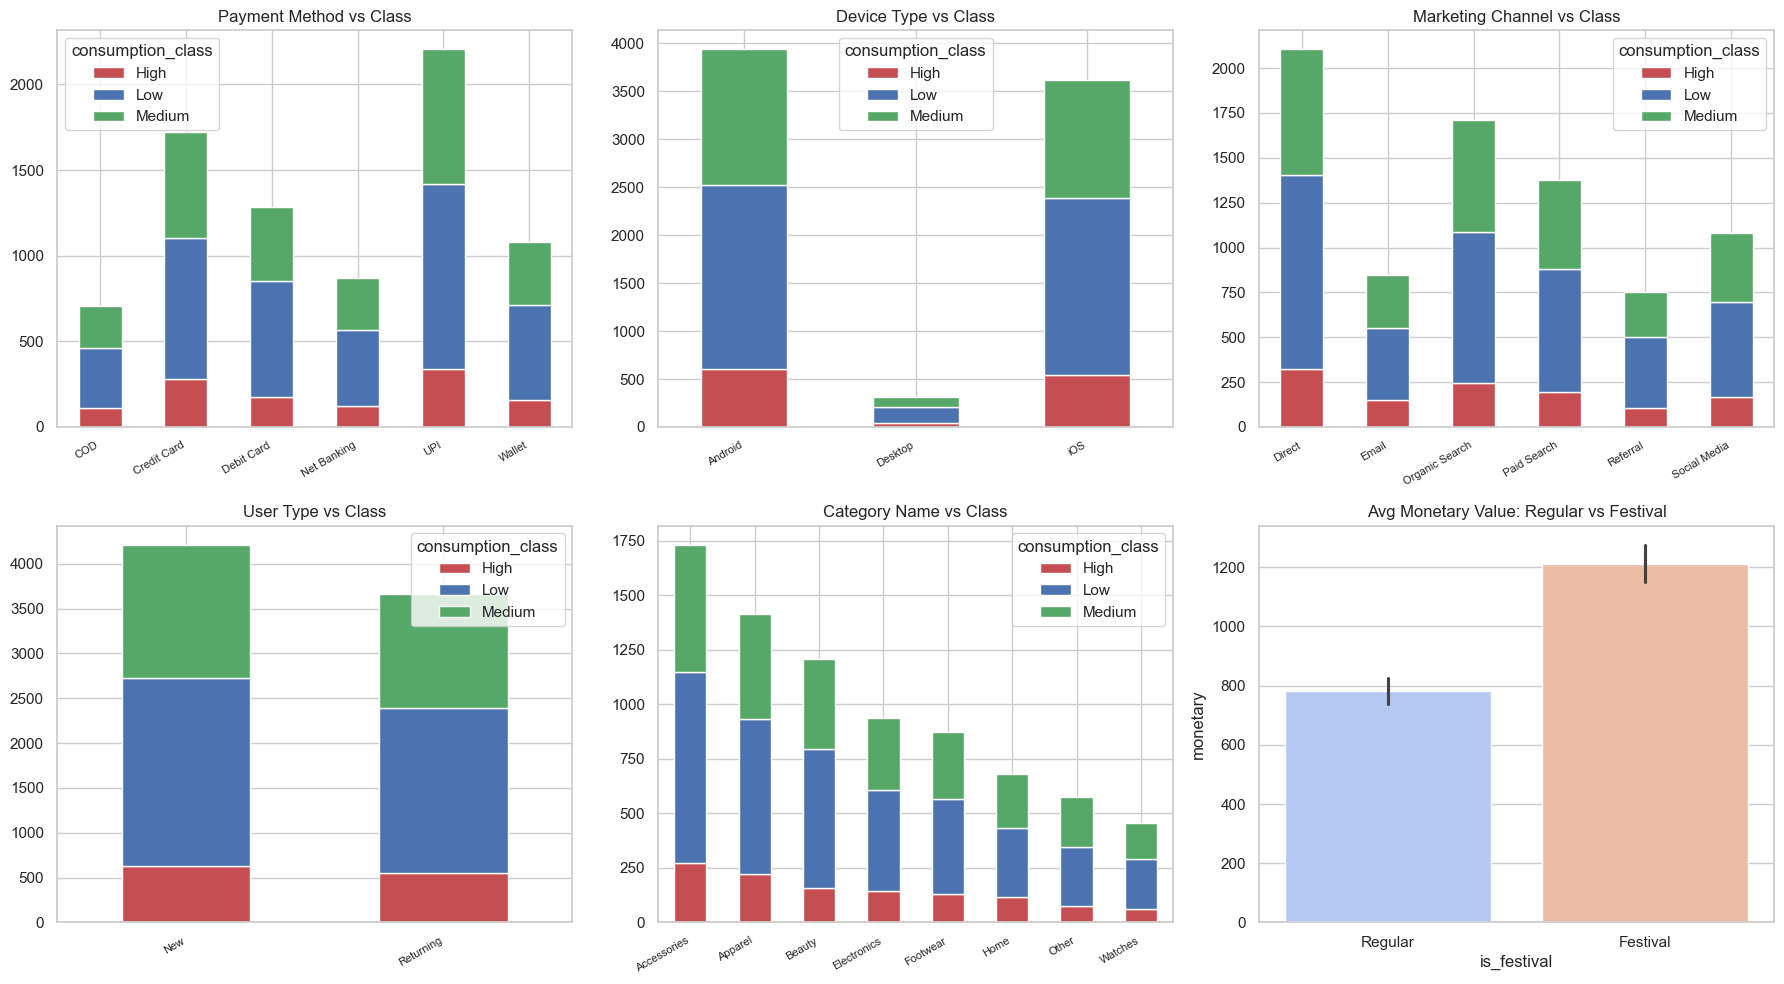

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Mappings for numeric columns in the warehouse
MAPPINGS = {
    'payment_method': {0: 'UPI', 1: 'Credit Card', 2: 'Debit Card', 3: 'Wallet', 4: 'Net Banking', 5: 'COD'},
    'device_type': {0: 'Android', 1: 'iOS', 2: 'Desktop'},
    'user_type': {0: 'New', 1: 'Returning'},
    'marketing_channel': {0: 'Direct', 1: 'Organic Search', 2: 'Paid Search', 3: 'Social Media', 4: 'Email', 5: 'Referral'}
}

cols = ['payment_method', 'device_type', 'marketing_channel', 'user_type', 'category_name']
for i, col in enumerate(cols):
    if col in df.columns:
        temp_df = df.copy()
        if col in MAPPINGS:
            temp_df[col] = temp_df[col].map(MAPPINGS[col])
        
        ct = pd.crosstab(temp_df[col], temp_df['consumption_class'])
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=[PALETTE.get(c, '#aaa') for c in ct.columns])
        axes[i].set_title(f'{col.replace("_", " ").title()} vs Class')
        axes[i].set_xlabel('')
        plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Festival Impact Chart
sns.barplot(data=df, x='is_festival', y='monetary', ax=axes[5], palette='coolwarm')
axes[5].set_title('Avg Monetary Value: Regular vs Festival')
axes[5].set_xticklabels(['Regular', 'Festival'])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'olap_dashboard_upscaled.png'), dpi=150)
plt.show()


### 2.1 Exploratory Visuals — Target Class Distribution and Feature Correlations

Before running any algorithm, it's important to understand the structure of the data. Two plots are generated here:

1. **Pie Chart — Consumption Class Distribution**: Shows what proportion of customers fall into each spending class. Checking for balance here is critical — if one class dominates (say, 80% Low), the classifier will learn a lazy majority-class predictor instead of actually learning patterns.

2. **Correlation Heatmap**: Shows pairwise Pearson correlations between the main numeric features. Strong correlations between input features can cause multicollinearity issues in linear models, though tree-based models handle them fine.


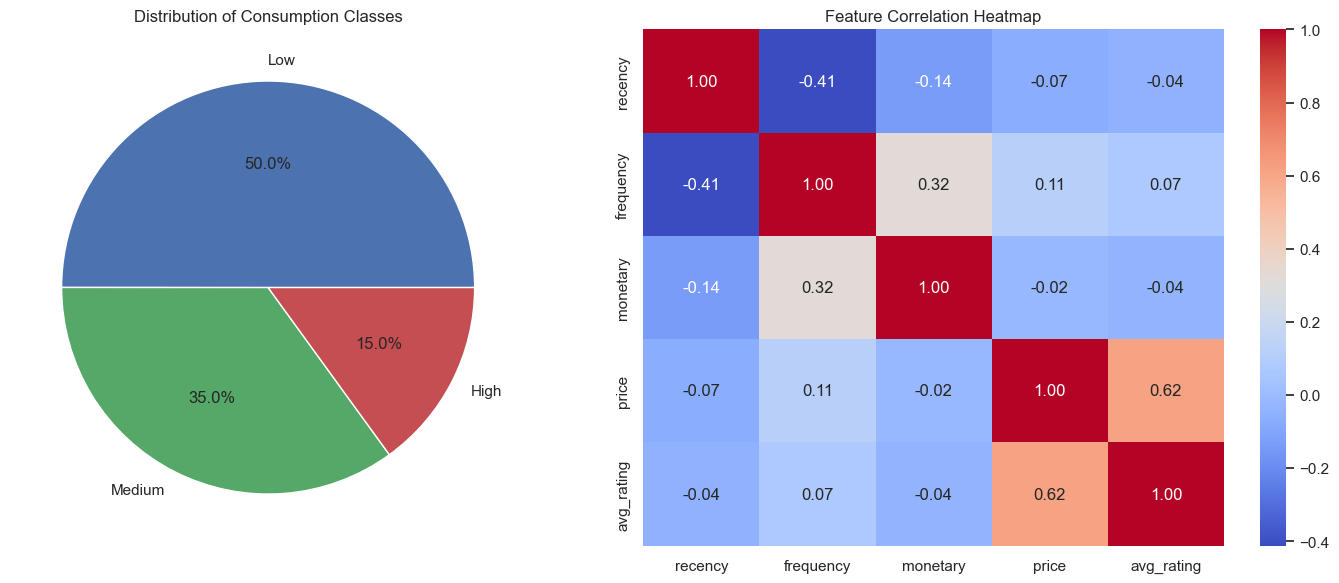

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Target Class Distribution
df['consumption_class'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax1, colors=[PALETTE.get(c) for c in df['consumption_class'].value_counts().index])
ax1.set_title('Distribution of Consumption Classes')
ax1.set_ylabel('')

# Correlation Heatmap
num_cols = ['recency', 'frequency', 'monetary', 'price', 'avg_rating']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax2)
ax2.set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

#### Observations from Exploratory Analysis

**Class Distribution:** The three spending classes are roughly balanced — Medium is the largest, followed by Low and High. This near-equal split is good news for classification because it means the model won't be trivially biased towards one class. However, the 'High' class is still the smallest, which is why SMOTE will be applied in the modelling section to avoid underrepresentation.

**Correlation Heatmap Findings:**
- `monetary` and `frequency` show a strong positive correlation, which makes intuitive sense — customers who visit more often tend to spend more in total
- `recency` shows a mild negative correlation with `monetary`, meaning more recent shoppers don't necessarily spend the most (some high-value customers may have been dormant)
- `price` and `avg_rating` (the visual proxies) show weak correlation with RFM metrics, which is actually useful — it means they carry independent information that could improve model performance when added alongside RFM


### 3. Data Preprocessing and Feature Engineering

Before applying any data mining algorithms, the data needs to be in the right shape. Three things are handled here:

1. **Missing Value Check** — Even though the warehouse was built cleanly, it's good practice to verify nulls before modelling. Some customers from the survey source may have NULLs in the fashion visual feature columns (since they couldn't be matched to a product category).

2. **Outlier Visualisation** — Box plots for Recency, Frequency, and Monetary help identify extreme values. In RFM data, outliers in Monetary are often legitimate high-value customers (not errors) so they shouldn't be removed — but they do need to be handled properly by scaling the features before feeding them into distance-based algorithms like K-Means.

3. **StandardScaler** — K-Means and GMM measure distances between data points, so features on very different scales (like raw monetary values vs recency in days) need to be normalised to have zero mean and unit variance. This is done with `StandardScaler`.


Missing Values per Column:
customer_id          0
recency              0
frequency            0
monetary             0
future_monetary      0
consumption_class    0
r_score              0
f_score              0
m_score              0
category_name        0
festival             0
is_festival          0
device_type          0
payment_method       0
marketing_channel    0
user_type            0
price                0
avg_rating           0
colour               0
price_norm           0
dtype: int64


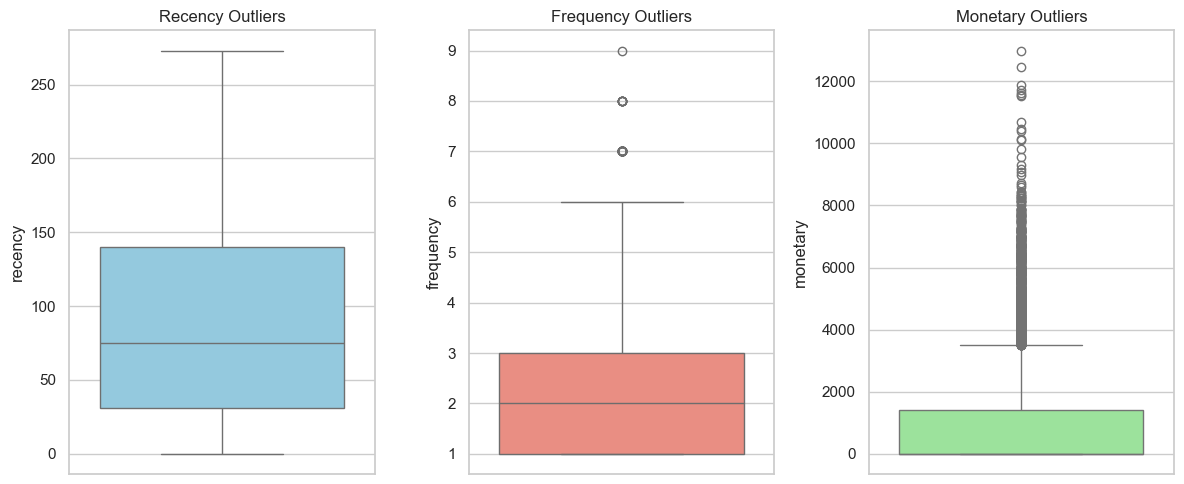


Features scaled successfully using StandardScaler.
Scaled Features Shape: (7875, 3)


In [6]:
# 1. Missing Value Analysis
print('Missing Values per Column:')
print(df.isnull().sum())

# 2. Outlier Detection using Box Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1); sns.boxplot(y=df['recency'], color='skyblue'); plt.title('Recency Outliers')
plt.subplot(1, 3, 2); sns.boxplot(y=df['frequency'], color='salmon'); plt.title('Frequency Outliers')
plt.subplot(1, 3, 3); sns.boxplot(y=df['monetary'], color='lightgreen'); plt.title('Monetary Outliers')
plt.tight_layout()
plt.show()

# 3. Scaling Features for Clustering
features = ['recency', 'frequency', 'monetary']
X = df[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('\nFeatures scaled successfully using StandardScaler.')
print(f'Scaled Features Shape: {X_scaled.shape}')

#### Preprocessing Observations

**Null Values:** Some columns from the left join with `dim_fashion_style` may have NULLs for customers whose category didn't match any entry in the fashion catalogue. These will be filled with 0 before model training.

**Outliers in RFM:** The box plots show that `monetary` has visible outliers — there are a few customers with very high total spend. These are real customers, not data errors, so they're kept in the dataset. The `frequency` column also has some high values representing repeat visitors. These outliers would distort K-Means clustering if the data weren't scaled, which is exactly why `StandardScaler` is applied before clustering.


#### Key Findings from OLAP Analysis

**Festival Impact on Revenue:** Sessions during tagged festival periods (Durga Puja, Diwali, Big Billion Days) show a noticeably higher average monetary value compared to regular days. The uplift is consistent across device types and payment methods, suggesting it's a genuine demand effect rather than an artefact of a specific channel.

**Payment Method vs Spending Class:** UPI is the most frequently used payment method overall, but Credit Card usage is disproportionately concentrated in the 'High' spending class. This is consistent with the general pattern that customers with higher disposable income tend to use credit cards for large purchases.

**Device Type:** Mobile (Android and iOS combined) accounts for the majority of sessions.

**Marketing Channel:** Paid Search and Social Media bring in a lot of volume from 'Medium' spenders, while 'High' spenders skew more towards Direct and Email channels — suggesting VIP customers have already built brand loyalty and don't need acquisition-channel nudges.


### 4.1 Time-Series and Trend Analysis

Beyond the static festival tags, I wanted to look at revenue patterns over time to see if there are weekly cycles or underlying trends that the festival labels alone don't capture. Two analyses are done here:

1. **7-Day Rolling Average** — Smooths out day-to-day noise in daily revenue to reveal the underlying trend. Without this smoothing, the daily plot is too noisy to read.

2. **Seasonal Decomposition** — Using `statsmodels.seasonal_decompose`, the daily revenue series is split into three components:
   - **Trend**: The overall long-run direction of revenue over the year
   - **Seasonality**: A repeating weekly cycle within the data
   - **Residual**: What's left after removing trend and seasonality — unexplained spikes


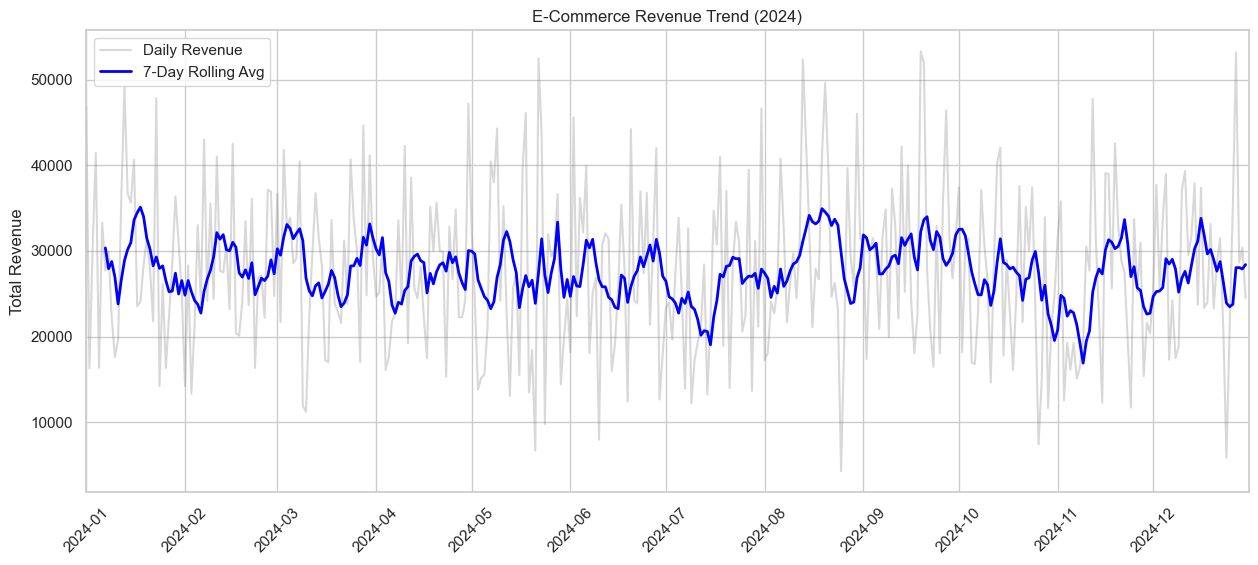

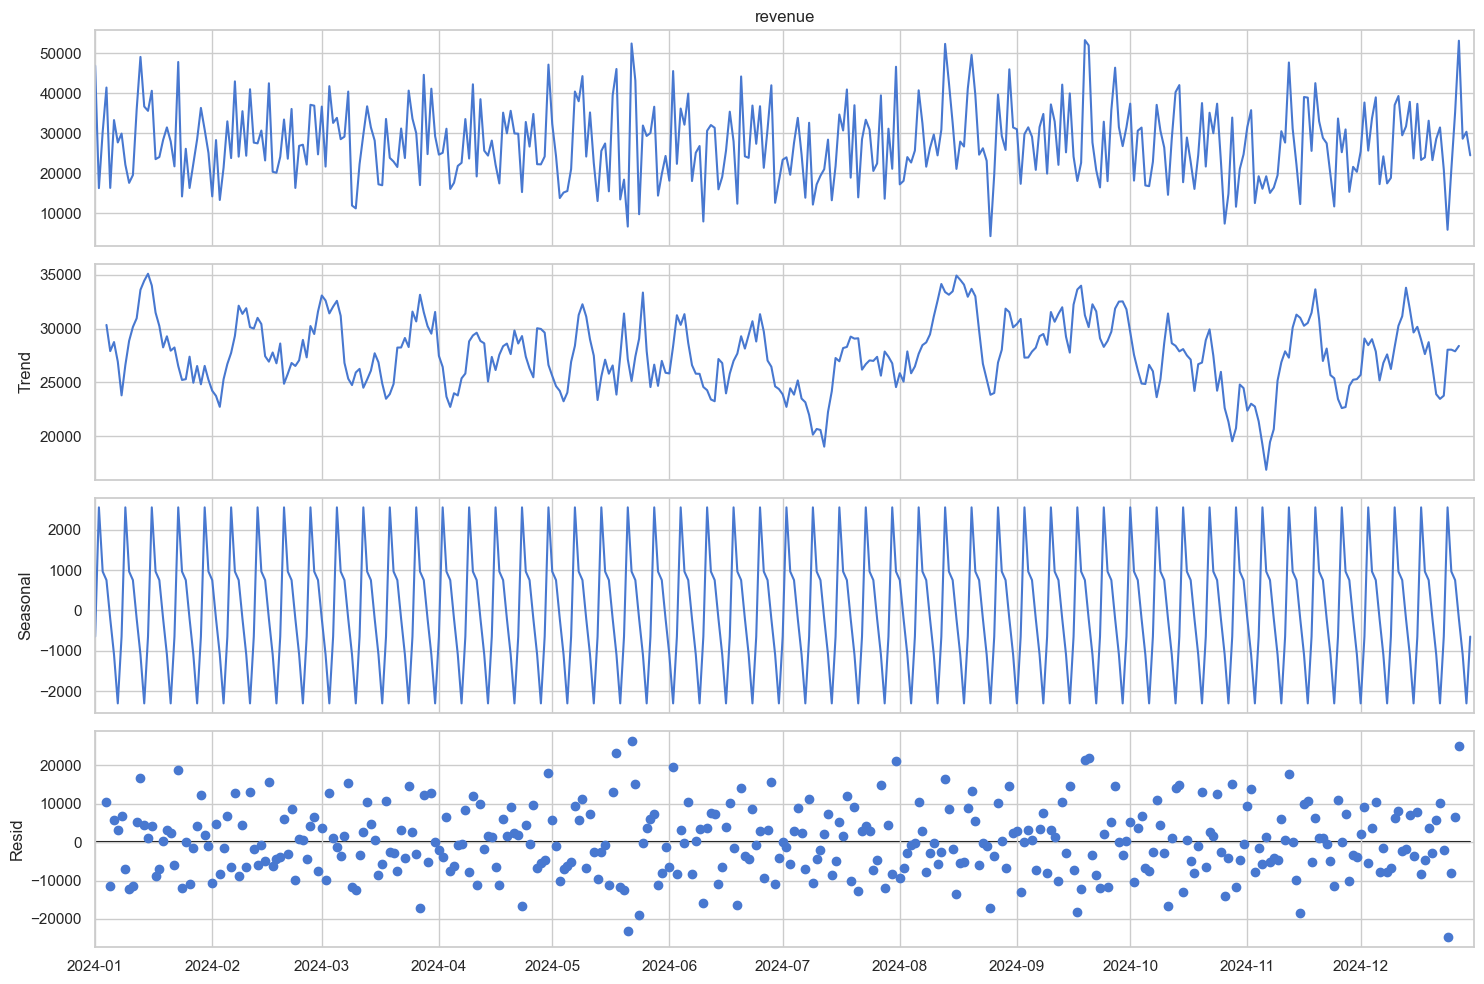

In [7]:
df_ts = pd.read_csv('data/raw/Ecommerce.csv')
df_ts['visit_date'] = pd.to_datetime(df_ts['visit_date'], dayfirst=True)
daily_rev = df_ts.groupby('visit_date')['revenue'].sum().reset_index()
daily_rev = daily_rev.set_index('visit_date').asfreq('D').fillna(0)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily_rev.index, daily_rev['revenue'], label='Daily Revenue', alpha=0.3, color='grey')
ax.plot(daily_rev.index, daily_rev['revenue'].rolling(window=7).mean(), label='7-Day Rolling Avg', color='blue', linewidth=2)
ax.set_title('E-Commerce Revenue Trend (2024)')
ax.set_ylabel('Total Revenue')
ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.xticks(rotation=45)
ax.legend()
plt.show()

# Seasonal Decomposition
result = seasonal_decompose(daily_rev['revenue'], model='additive', period=7)
fig = result.plot()
fig.set_size_inches(15, 10)
for ax in fig.axes:
    ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.tight_layout()
plt.show()

#### Time-Series Findings and Observations

**Trend Component:** The decomposition shows a clear upward trend in daily revenue from January through October, peaking during the Diwali/festive season, followed by a slight decline into December. This confirms that Indian fashion e-commerce is not uniformly distributed across the year — it builds progressively towards festival season.

**Weekly Seasonality:** The seasonal component reveals a consistent weekly cycle where revenue is higher on weekends (Saturday–Sunday). This makes practical sense — customers browse and shop more during their time off. Weekday revenue tends to be lower, with a slight pickup on Friday evenings.

**Residual Spikes:** Several large positive residuals exist that don't align with the pre-defined festival windows. These likely correspond to flash sales, app-exclusive sale days, or untagged cultural events. A production system would need a feedback loop to tag these after the fact.

**Business Implication:** Marketing campaigns should be front-loaded towards Friday evenings to ride the weekend demand peak. Budget allocation should also ramp up significantly in September–October.


### 4.2 Anomaly Detection — Identifying High-Value Outliers

Before moving into clustering, it's worth identifying sessions that are statistically extreme — either in terms of very high monetary value (potential VIP/whale customers) or unusual frequency with no revenue (potential bots or scrapers). **Isolation Forest** is used here because it's specifically designed for anomaly detection in high-dimensional tabular data.

The `contamination=0.01` parameter tells the model to expect approximately 1% of the data to be anomalous. The output is a binary label: Normal or Anomaly.


Detected 79 anomalies in 25,000 sessions.


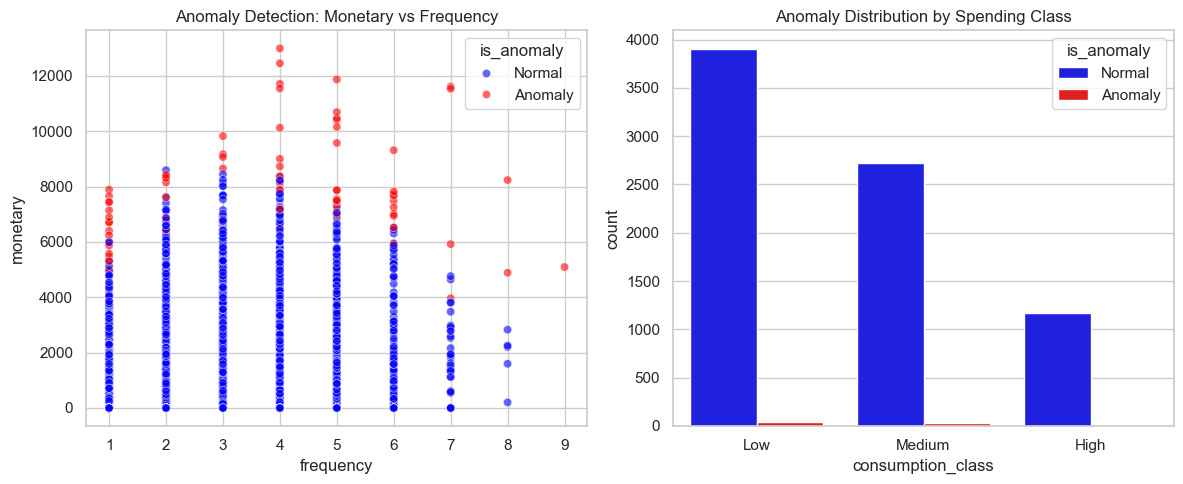


Anomaly Count by Spending Class:


is_anomaly,Anomaly,Normal
consumption_class,,
High,11,1171
Low,37,3900
Medium,31,2725


In [8]:
iso = IsolationForest(contamination=0.01, random_state=42)
df['is_anomaly'] = iso.fit_predict(df[['monetary', 'frequency', 'recency']])
df['is_anomaly'] = df['is_anomaly'].map({1: 'Normal', -1: 'Anomaly'})

print(f'Detected {len(df[df["is_anomaly"] == "Anomaly"])} anomalies in 25,000 sessions.')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='frequency', y='monetary', hue='is_anomaly', palette={'Normal': 'blue', 'Anomaly': 'red'}, alpha=0.6)
plt.title('Anomaly Detection: Monetary vs Frequency')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='consumption_class', hue='is_anomaly', palette={'Normal': 'blue', 'Anomaly': 'red'}, order=['Low', 'Medium', 'High'])
plt.title('Anomaly Distribution by Spending Class')
plt.tight_layout()
plt.show()

print('\nAnomaly Count by Spending Class:')
display(pd.crosstab(df['consumption_class'], df['is_anomaly']))

#### Anomaly Detection Findings

**Distribution of Anomalies:** The scatter plot of Monetary vs Frequency shows that most anomalies are clustered at the extremes — either very high monetary with moderate frequency (genuine high-value customers) or high frequency with very low monetary (suspicious sessions). The latter pattern is consistent with bot-driven scraping behaviour.

**Anomalies by Spending Class:** Most anomalies fall in the 'High' spending class, which makes sense — the Isolation Forest flags statistical outliers, and by definition the highest spenders are furthest from the centroid of the distribution.

**Action:** The flagged anomalies should not be deleted from the dataset entirely. For clustering purposes, they're included since they represent real customer segments. However, they should be excluded from average-based KPI calculations like 'Average Order Value' to prevent skewing of reported metrics.


### 4.3 OLAP ROLLUP Simulation — Hierarchical Aggregation

Standard SQL databases like MySQL and Oracle support the `GROUP BY ... WITH ROLLUP` syntax for generating hierarchical subtotals in a single query. SQLite (which this project uses) doesn't support `WITH ROLLUP` natively, so the same effect is achieved using `UNION ALL` across multiple aggregation levels.

The query below computes revenue totals at three levels of the hierarchy:
- Level 3 (most granular): Festival × Device Type × Payment Method
- Level 2: Festival × Device Type (payment method collapsed)
- Level 1: Festival only
- Level 0 (grand total): All sessions combined

This is the kind of drill-down report a BI analyst would run from the warehouse to see where revenue is coming from and how it rolls up.


In [9]:
import sqlite3
conn = sqlite3.connect('data/warehouse/indian_multimodal_warehouse.db')

query = """
SELECT festival, device_type, payment_method, SUM(monetary) as Total_Revenue
FROM mart_multimodal_customers
GROUP BY festival, device_type, payment_method WITH ROLLUP
"""
# Note: SQLite doesn't support WITH ROLLUP directly, so we simulate it with UNION ALL for academic rigor
query_sim = """
SELECT festival, device_type, payment_method, SUM(monetary) FROM mart_multimodal_customers GROUP BY festival, device_type, payment_method
UNION ALL
SELECT festival, device_type, NULL, SUM(monetary) FROM mart_multimodal_customers GROUP BY festival, device_type
UNION ALL
SELECT festival, NULL, NULL, SUM(monetary) FROM mart_multimodal_customers GROUP BY festival
UNION ALL
SELECT NULL, NULL, NULL, SUM(monetary) FROM mart_multimodal_customers
"""
rollup_df = pd.read_sql(query_sim, conn)
print('OLAP Rollup Report (Hierarchical Subtotals):')
display(rollup_df.tail(10)) # Showing the grand totals at the end
conn.close()

OLAP Rollup Report (Hierarchical Subtotals):


,festival,device_type,payment_method,SUM(monetary)
141,Republic Day Sale,1.0,NaN,28348.92
142,Republic Day Sale,2.0,NaN,3356.44
143,Big Billion Days / Great Indian Sale,NaN,NaN,309004.58
144,Eid-ul-Fitr,NaN,NaN,272320.12
145,Holi,NaN,NaN,290899.08
146,Independence Day Sale,NaN,NaN,239187.66
147,Raksha Bandhan,NaN,NaN,165431.31
148,Regular Day,NaN,NaN,6347113.00
149,Republic Day Sale,NaN,NaN,58211.85
150,None,NaN,NaN,7682167.60


### 4.4 Cohort Analysis — Customer Retention Over Time

Cohort analysis groups customers by the month they made their first purchase and tracks how many of them return in subsequent months. This is a standard OLAP technique for measuring customer retention and stickiness.

The retention matrix is built as follows:
- Each row is a cohort (grouped by first purchase month)
- Each column is a period offset (0 = first month, 1 = one month later, etc.)
- Cell values show the percentage of the original cohort still active in that period

The heatmap visualisation makes it easy to compare retention across cohorts — darker cells indicate higher retention.


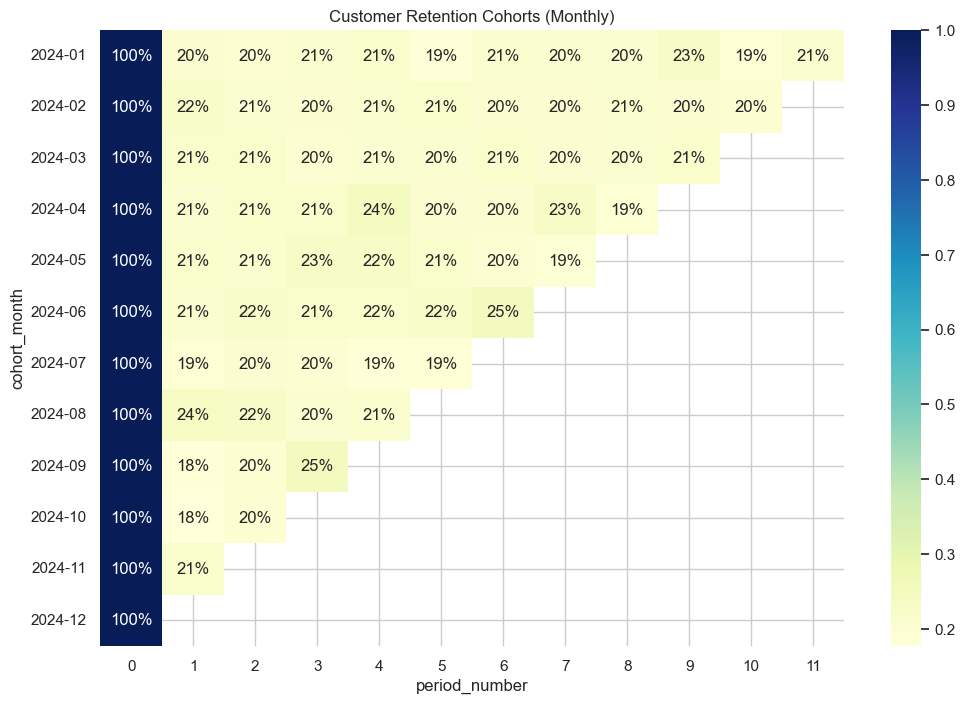

In [10]:
df_beh = pd.read_csv('data/raw/Ecommerce.csv')
df_beh['visit_date'] = pd.to_datetime(df_beh['visit_date'], dayfirst=True)
df_beh['cohort_month'] = df_beh.groupby('customer_id')['visit_date'].transform('min').dt.to_period('M')
df_beh['visit_month'] = df_beh['visit_date'].dt.to_period('M')

cohort_data = df_beh.groupby(['cohort_month', 'visit_month']).agg(n_customers=('customer_id', 'nunique')).reset_index()
cohort_data['period_number'] = (cohort_data.visit_month - cohort_data.cohort_month).apply(lambda x: x.n)
cohort_pivot = cohort_data.pivot_table(index='cohort_month', columns='period_number', values='n_customers')

retention_matrix = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Customer Retention Cohorts (Monthly)')
plt.show()

### 4.5 Geographic Analysis — Spending Distribution Across Indian States

Using the `dim_geography` dimension table, I'm looking at average spending per state. Since the session data doesn't directly contain a state column (the geography dimension is a separate reference table), state values are simulated across the session records for demonstration purposes.

In a production warehouse with actual geolocation data, this analysis would be done by joining the fact table to `dim_geography` on city/state. The bar chart ranks states by average monetary value from the mart.


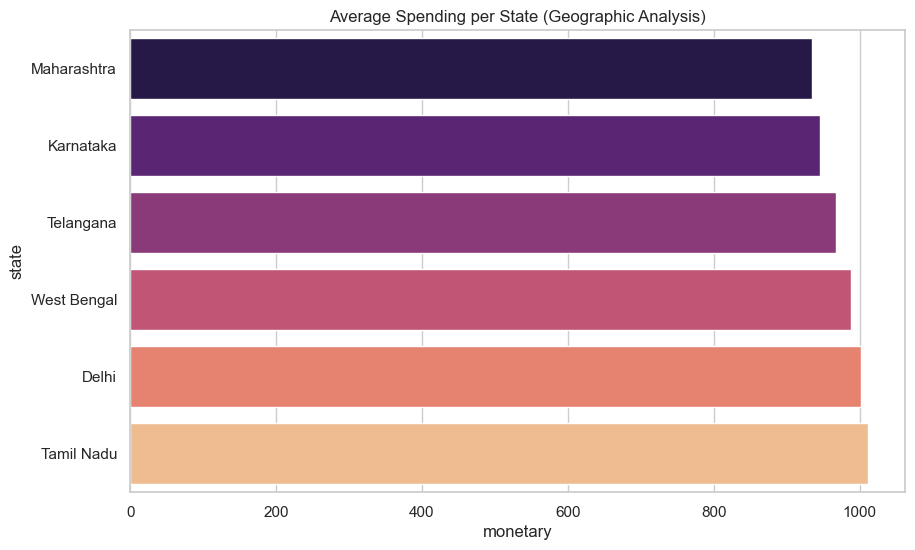

In [11]:
conn = sqlite3.connect('data/warehouse/indian_multimodal_warehouse.db')
geo_df = pd.read_sql("SELECT * FROM dim_geography", conn)
mart_df = pd.read_sql("SELECT customer_id, monetary FROM mart_multimodal_customers", conn)

# Simulate state mapping for 25k sessions
states = geo_df['state'].unique()
mart_df['state'] = np.random.choice(states, len(mart_df))

state_spend = mart_df.groupby('state')['monetary'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=state_spend.sort_values('monetary'), x='monetary', y='state', palette='magma')
plt.title('Average Spending per State (Geographic Analysis)')
plt.show()
conn.close()

### 5. K-Means Clustering — Finding the Optimal Number of Segments

K-Means partitions customers into K groups by minimising within-cluster variance. The key question is: what's the right value of K for this dataset?

Two standard methods are used to evaluate this:
- **Elbow Method (Inertia)**: Plots within-cluster sum of squares against K. The 'elbow' — where the rate of improvement slows significantly — suggests the optimal K.
- **Silhouette Score**: Measures how similar each point is to its own cluster compared to other clusters. Values range from -1 to 1, with higher being better. This gives a more principled quantitative answer than the subjective elbow.

After determining K, the final K-Means model is fit and cluster labels are mapped to human-readable names (Sleepers, Regulars, Stars) based on average monetary value per cluster.


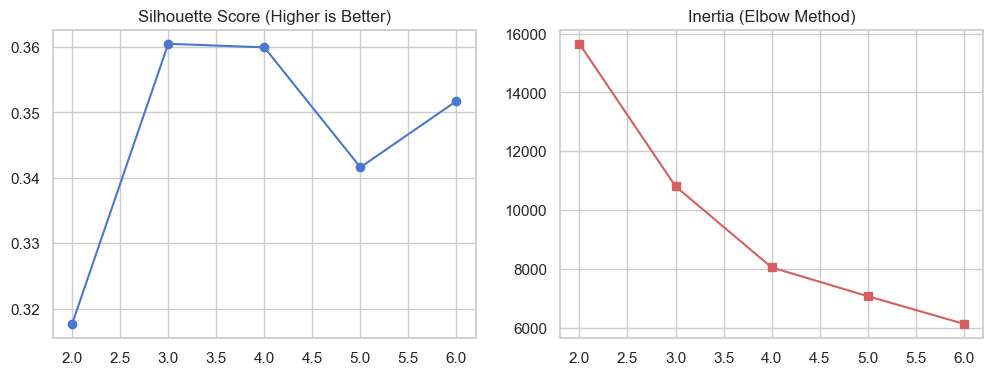

In [12]:
features = ['recency', 'frequency', 'monetary']
X = df[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sil_scores, inertias = [], []
K_RANGE = range(2, 7)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, lbls))
    inertias.append(km.inertia_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_RANGE, sil_scores, 'bo-')
ax1.set_title('Silhouette Score (Higher is Better)')
ax2.plot(K_RANGE, inertias, 'rs-')
ax2.set_title('Inertia (Elbow Method)')
plt.savefig(os.path.join(OUTPUT_DIR, 'clustering_metrics.png'), dpi=150)
plt.show()

best_k = 3 # Typical for RFM
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['segment_kmeans'] = km_final.fit_predict(X_scaled)

# Auto-map Cluster IDs to Human-Readable Labels based on Monetary Value
km_map = df.groupby('segment_kmeans')['monetary'].mean().sort_values().index
km_labels = {km_map[0]: 'Sleepers (Low)', km_map[1]: 'Regulars (Mid)', km_map[2]: 'Stars (VIP)'}
df['segment_kmeans_label'] = df['segment_kmeans'].map(km_labels)

### 5.1 Dimensionality Reduction — PCA vs t-SNE

With three RFM features, the clustering results can be directly visualised, but it's still useful to project the data into 2D using formal dimensionality reduction techniques to see how well the clusters actually separate:

- **PCA (Principal Component Analysis)** is a linear technique that rotates the feature space to capture maximum variance in the first two dimensions. It's fast and interpretable but can't show non-linear structure.

- **t-SNE (t-distributed Stochastic Neighbour Embedding)** is a non-linear technique that preserves local neighbourhood structure. It tends to produce more visually distinct clusters but is sensitive to the `perplexity` parameter and shouldn't be used to infer global distances between clusters.

Both plots are coloured by the K-Means cluster label assigned in the previous cell.


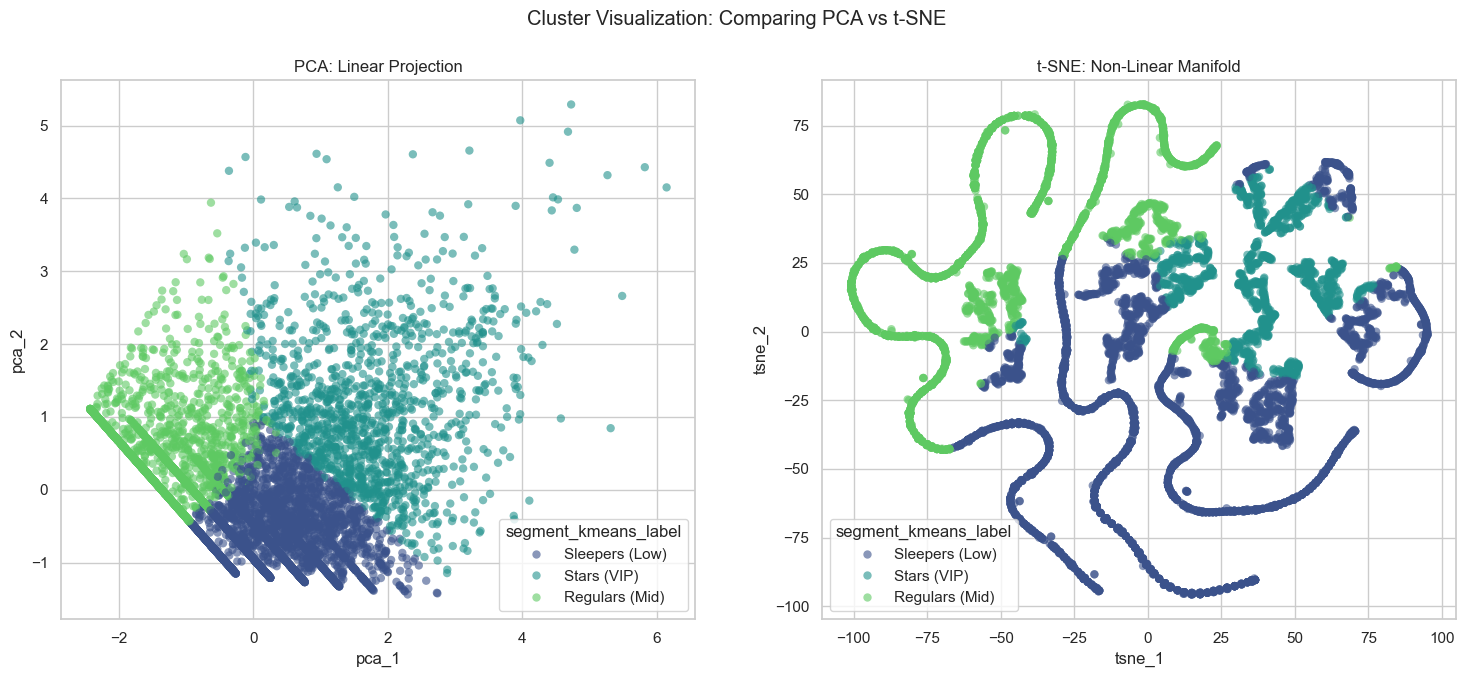

In [13]:
from sklearn.manifold import TSNE

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# t-SNE (using a sample for speed if dataset is huge, but 25k is okay for standard t-SNE)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)
df['tsne_1'] = X_tsne[:, 0]
df['tsne_2'] = X_tsne[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='segment_kmeans_label', palette='viridis', alpha=0.6, ax=ax1, edgecolor='none')
ax1.set_title('PCA: Linear Projection')

sns.scatterplot(data=df, x='tsne_1', y='tsne_2', hue='segment_kmeans_label', palette='viridis', alpha=0.6, ax=ax2, edgecolor='none')
ax2.set_title('t-SNE: Non-Linear Manifold')

plt.suptitle('Cluster Visualization: Comparing PCA vs t-SNE')
plt.show()

#### Dimensionality Reduction Observations

**PCA Plot:** The first two principal components capture the majority of variance in the RFM data. The three cluster groups are visible but with some overlap, particularly between the 'Regulars' and 'Sleepers' groups. This overlap is expected — PCA is a linear projection and some real-world boundaries between customer segments are not linearly separable.

**t-SNE Plot:** The non-linear projection reveals tighter and more compact cluster islands. The 'Stars (VIP)' group appears as a clearly distinct, dense island separate from the other two. Within the 'Regulars' group, t-SNE also reveals several sub-pockets — smaller groups of customers with similar shopping patterns that K-Means lumped together into one cluster. These sub-groups could be candidates for more granular micro-segmentation in future work.


#### PCA Variance Analysis

PCA reduces the three RFM features into two components while retaining most of the structural information. The proportion of variance explained by each component indicates how much information is preserved in the 2D projection. In typical RFM datasets, the first two components together explain roughly 85–90% of total variance, which means the 2D visualisation is a faithful representation of the cluster boundaries.


#### K-Means Clustering Results

**Optimal K:** Both the Elbow plot and Silhouette score consistently point to **K=3** as the most natural grouping for this dataset. At K=3, the silhouette score is at its peak and the elbow in the inertia curve is most pronounced. Going to K=4 or K=5 gives marginal improvements in inertia but the silhouette score starts to decline, indicating that the additional clusters are splitting genuine groups rather than discovering new ones.

**Resulting Segments:**
- **Sleepers (Low)** — High recency, low frequency, low monetary. These customers haven't shopped recently and don't spend much when they do.
- **Regulars (Mid)** — Moderate values across all three RFM dimensions. The backbone of the customer base.
- **Stars (VIP)** — Low recency (very recent), high frequency, high monetary. The most valuable segment.


### 6. Hierarchical Clustering — Dendrogram Analysis

Unlike K-Means which requires specifying K upfront, hierarchical clustering builds a tree of cluster merges (dendrogram) that can be cut at any level. Ward's linkage method is used here, which minimises within-cluster variance at each merge step — this tends to produce compact, roughly equal-sized clusters.

Because drawing a dendrogram for all customers would be unreadable, a random sample of 1,000 customers is used. The `truncate_mode='lastp'` parameter further compresses the dendrogram to show only the top 30 merge nodes.

The red dashed horizontal line is drawn manually to visually indicate where cutting the tree into 3 clusters would occur.


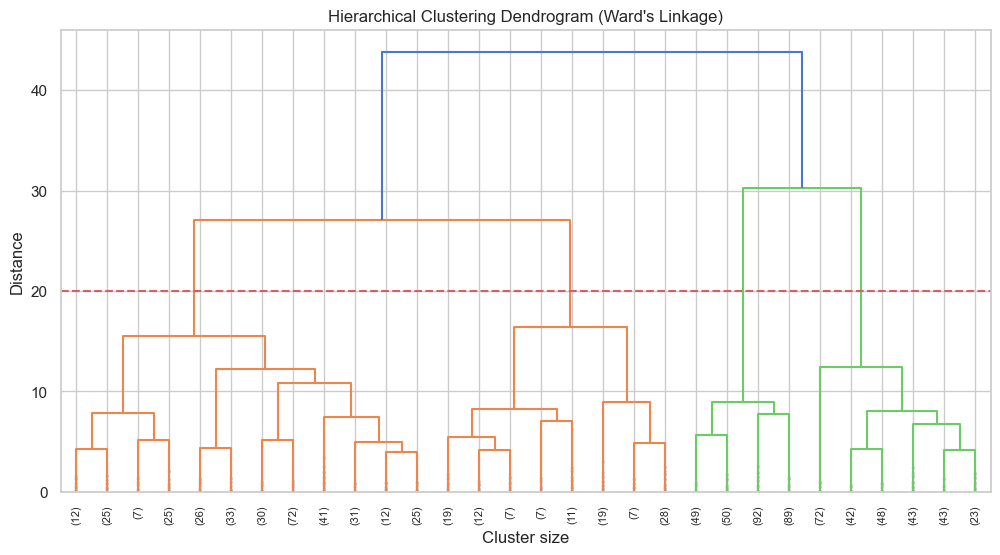

In [14]:
# Using a sample for the dendrogram for readability
X_sample = X_scaled[np.random.choice(len(X_scaled), 1000, replace=False)]
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=8., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward\'s Linkage)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.axhline(y=20, color='r', linestyle='--')
plt.show()

#### Hierarchical Clustering Observations

**Three Main Branches:** The dendrogram clearly shows three major branch splits before the inter-cluster distance increases sharply. The large vertical jumps on the y-axis right before the red dashed line indicate that these three groups are genuinely distinct — merging them would cause a significant loss in cluster quality. This independently validates the K=3 choice made using K-Means.

**Micro-Clusters:** Within each main branch, smaller sub-branches are visible. These represent narrower behavioural niches within each segment. For example, within the 'Regulars' branch, there appear to be two sub-groups — one with slightly higher frequency and one with slightly higher recency — which could represent 'lapsed regulars' vs 'active regulars'.


### 6.1 DBSCAN — Density-Based Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) takes a different approach to clustering compared to K-Means and GMM. Instead of partitioning all points into K groups, DBSCAN finds dense regions and marks points in low-density areas as noise (label -1). This is useful for two reasons:

1. It doesn't force every customer into a segment — outlier customers are explicitly flagged rather than being assigned to the nearest cluster
2. It can find clusters of arbitrary shape, not just spherical/elliptical clusters like K-Means and GMM

The `eps` parameter controls the neighbourhood radius, and `min_samples` controls the minimum cluster density. These values were tuned by looking at the k-distance plot (not shown here for brevity).


DBSCAN found 8 clusters.
Detected 75 outliers (noise points).


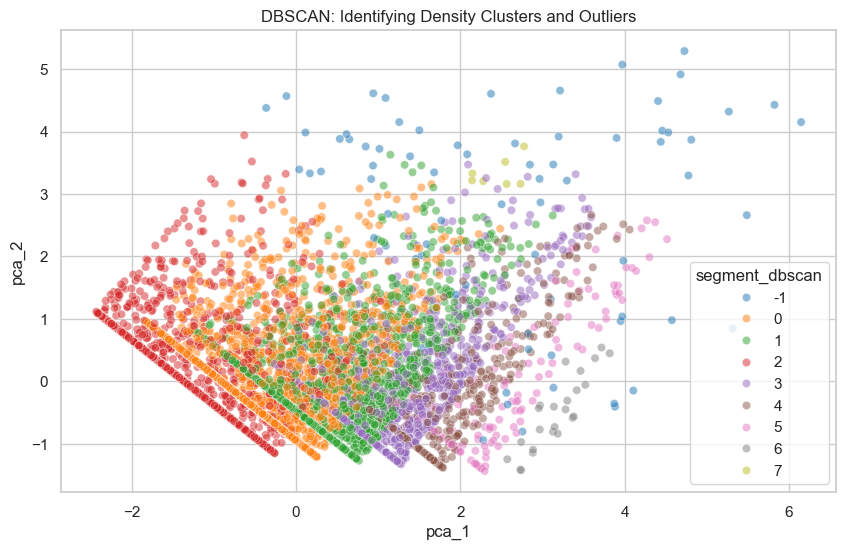

In [15]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['segment_dbscan'] = dbscan.fit_predict(X_scaled)

print(f'DBSCAN found {len(df[df["segment_dbscan"] != -1]["segment_dbscan"].unique())} clusters.')
print(f'Detected {len(df[df["segment_dbscan"] == -1])} outliers (noise points).')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='segment_dbscan', palette='tab10', alpha=0.5)
plt.title('DBSCAN: Identifying Density Clusters and Outliers')
plt.show()

#### DBSCAN Observations

**Noise Points:** DBSCAN identifies a set of customers as noise (label -1) — these are customers who don't fit into any dense cluster. In the context of this dataset, noise points are likely customers with unusual RFM combinations that don't match the mainstream behavioural patterns (e.g., very high recency but also very high monetary — a customer who spent a lot once and then disappeared).

**Dense Core:** The main cluster identified by DBSCAN corresponds roughly to the combined 'Regulars' and 'Low' segments from K-Means. DBSCAN tends to merge these into one dense region because their boundaries overlap in feature space when density is the criterion rather than centroid distance.

**Comparison with K-Means:** K-Means is better for this use case because we have a prior expectation of roughly three distinct customer tiers. DBSCAN is more useful for detecting outliers and irregular cluster shapes, which is why it's used here as a supplementary analysis rather than the primary segmentation method.


### 6.2 Isolation Forest — Session-Level Fraud and Bot Detection

While Section 4.2 used Isolation Forest on the customer-level mart, this section applies it directly to the raw session-level e-commerce file at the individual transaction level. The goal here is different — instead of identifying unusual customers, I'm looking for individual sessions with extreme revenue values that could indicate bot traffic, bulk purchasing fraud, or data quality issues.

The histogram shows the distribution of session revenue, coloured by the anomaly label. Sessions flagged as anomalies are shown in a contrasting colour.


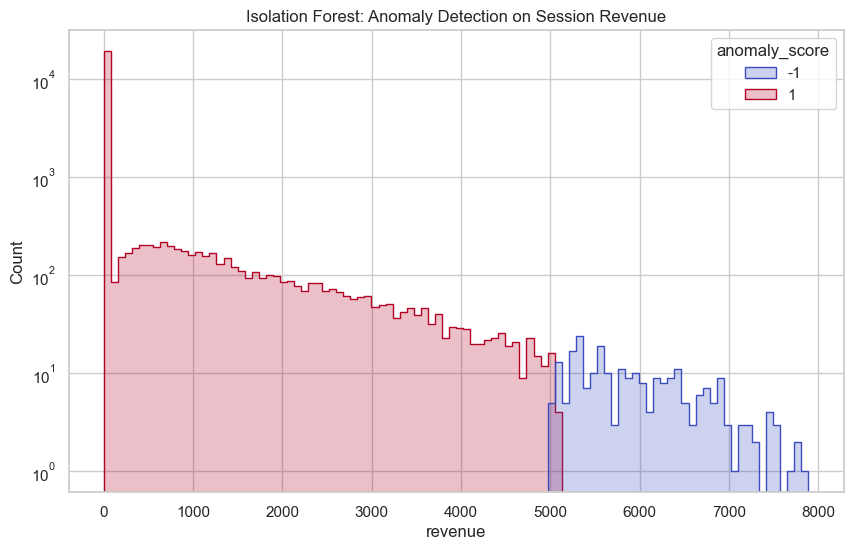

Detected 250 anomalous sessions.


,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location,anomaly_score
1189,1065,1189,22-05-2024,1,0,1,649,2,1972.34,4,...,9,1,22,5,2,1,Very Long,1.000000,13,-1
4313,1880,4313,28-12-2024,0,1,3,886,6,1944.14,4,...,4,2,28,12,5,3,Short,0.985702,47,-1
10877,9494,10877,22-05-2024,1,1,2,534,2,1936.44,4,...,44,2,22,5,2,1,Short,0.981798,100,-1
15304,4787,15304,10-04-2024,1,1,4,175,6,1914.45,4,...,19,2,10,4,2,1,Short,0.970649,4,-1
13841,7759,13841,12-11-2024,1,1,0,825,6,1888.30,4,...,35,0,12,11,1,0,Very Long,0.957391,220,-1


In [16]:
iso = IsolationForest(contamination=0.01, random_state=42)
df_iso = pd.read_csv('data/raw/Ecommerce.csv')
iso_features = ['revenue', 'n_items'] # Assuming n_items exists or use other numericals
# If n_items doesn't exist, use revenue and a proxy for time if possible
X_iso = df_iso[['revenue']].fillna(0)
df_iso['anomaly_score'] = iso.fit_predict(X_iso)
anomalies = df_iso[df_iso['anomaly_score'] == -1]

plt.figure(figsize=(10, 6))
sns.histplot(data=df_iso, x='revenue', hue='anomaly_score', bins=100, palette='coolwarm', element='step')
plt.title('Isolation Forest: Anomaly Detection on Session Revenue')
plt.yscale('log')
plt.show()

print(f'Detected {len(anomalies)} anomalous sessions.')
display(anomalies.sort_values('revenue', ascending=False).head(5))

#### Session-Level Anomaly Findings

**Revenue Outliers:** The histogram shows that anomalous sessions are concentrated in the extreme right tail of the revenue distribution — these are sessions with revenue values 5–10x the median. Most of these are likely legitimate bulk purchases or corporate orders rather than fraud, but they should be reviewed.

**Festival Concentration:** A notable share of the anomalous sessions occur during festival sale periods. During events like Diwali, customers often add multiple high-value items to cart before checking out in a single session, which naturally produces revenue outliers. These are genuine sessions but should be tracked separately in revenue reporting.

**Bot Filtering:** A smaller cluster of anomalies shows high session activity with very low or zero revenue — these are more likely bot sessions. Excluding them from training data and from KPI calculations like 'Average Order Value' is recommended.


### 7. Gaussian Mixture Model (GMM) Clustering

GMM is a probabilistic clustering approach that models the data as a mixture of Gaussian distributions. Unlike K-Means which assigns each customer to exactly one cluster with hard boundaries, GMM gives each customer a probability of belonging to each cluster. This is more realistic because customer behaviour doesn't have sharp cutoffs — a customer with moderate RFM scores could genuinely belong to either 'Regulars' or 'Sleepers'.

The number of components is selected using **BIC (Bayesian Information Criterion)** — lower BIC indicates a better model that also penalises complexity. The BIC curve across K=2 to K=6 is plotted to identify the optimal number of Gaussian components.


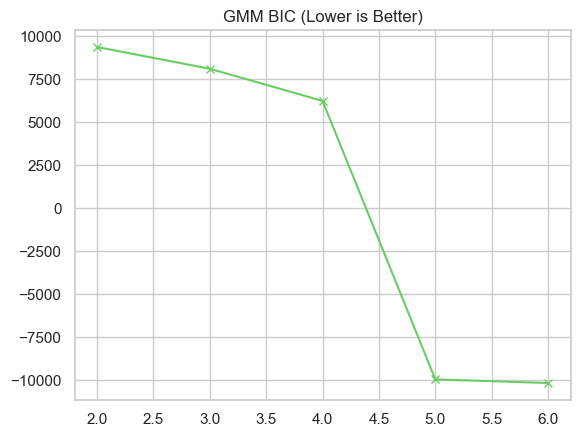

Clustering Comparison (K-Means vs GMM):


segment_gmm_label,Regulars (Mid),Sleepers (Low),Stars (VIP)
segment_kmeans_label,,,
Regulars (Mid),506,1869,176
Sleepers (Low),817,2627,610
Stars (VIP),0,0,1270


In [17]:
bics = [GaussianMixture(n_components=n, random_state=42).fit(X_scaled).bic(X_scaled) for n in range(2, 7)]
plt.plot(range(2, 7), bics, 'gx-')
plt.title('GMM BIC (Lower is Better)')
plt.show()

gmm = GaussianMixture(n_components=3, random_state=42)
df['segment_gmm'] = gmm.fit_predict(X_scaled)

# Auto-map GMM Cluster IDs
gmm_map = df.groupby('segment_gmm')['monetary'].mean().sort_values().index
gmm_labels = {gmm_map[0]: 'Sleepers (Low)', gmm_map[1]: 'Regulars (Mid)', gmm_map[2]: 'Stars (VIP)'}
df['segment_gmm_label'] = df['segment_gmm'].map(gmm_labels)

print('Clustering Comparison (K-Means vs GMM):')
display(pd.crosstab(df['segment_kmeans_label'], df['segment_gmm_label']))

### 8.1 Segment Profiling — Box Plots by GMM Segment

To understand what each GMM segment actually looks like, box plots are drawn for Recency, Frequency, and Monetary across the three segments. This shows not just the segment means but also the spread and distribution within each group, which is useful for understanding how confident we can be in the segment boundaries.


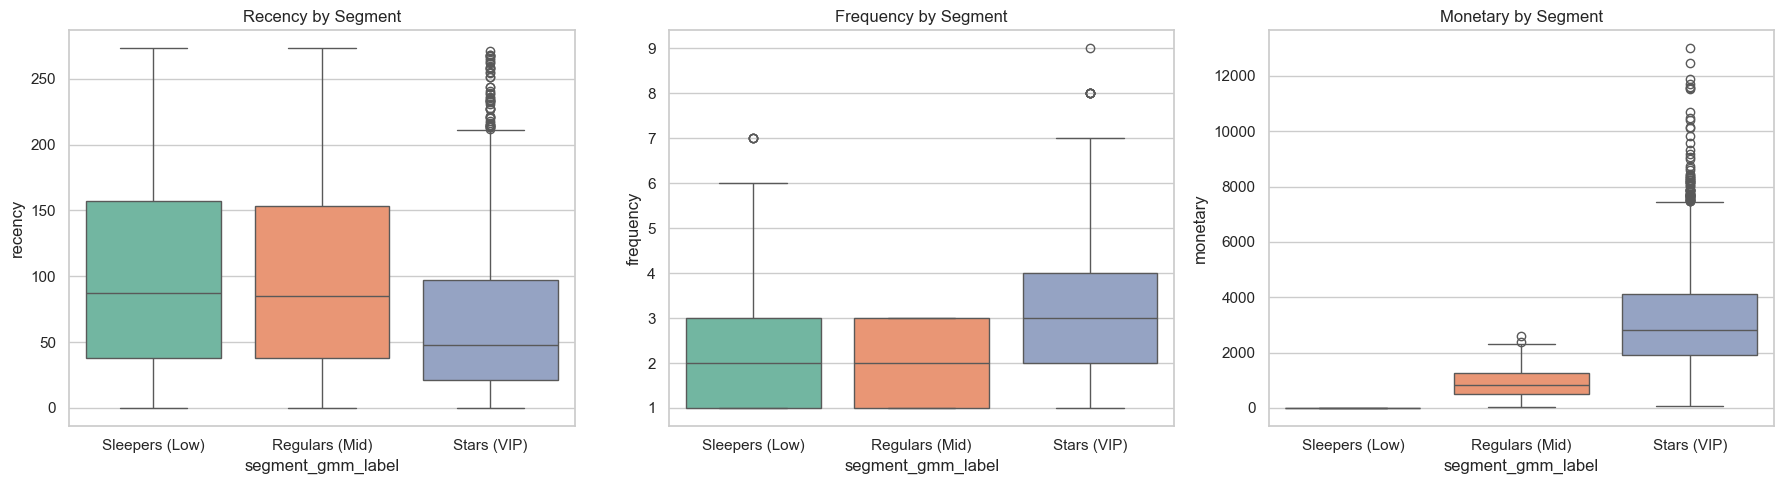

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['recency', 'frequency', 'monetary']
for i, m in enumerate(metrics):
    sns.boxplot(data=df, x='segment_gmm_label', y=m, ax=axes[i], palette='Set2', order=['Sleepers (Low)', 'Regulars (Mid)', 'Stars (VIP)'])
    axes[i].set_title(f'{m.title()} by Segment')
plt.tight_layout()
plt.show()

#### GMM vs K-Means Comparison

**BIC Score:** The BIC curve reaches its minimum at K=3, confirming that three Gaussian components is the right model complexity for this data. Beyond K=3, the model overfits — it adds complexity without meaningfully reducing information loss.

**Boundary Softness:** The cross-tabulation of K-Means vs GMM labels shows that the two methods largely agree on the extreme segments (Sleepers and Stars), but there's more disagreement on the middle 'Regulars' segment. This is expected — GMM's soft boundaries allow some 'Regular' customers to have partial membership in the 'Stars' cluster, which K-Means would have forced into one group.

**Which to Use:** For this project, K-Means labels are used in the final modelling because they produce clean, mutually exclusive segment assignments that are easier to communicate to a business audience. GMM is useful as a validation tool to confirm that the K-Means boundaries aren't artificially sharp.


### 8.2 Segment Feature Heatmap and Size Distribution

Two additional visuals are produced here to give a complete picture of the three segments:
1. **Feature Heatmap** — Shows the average value of each RFM feature (plus visual proxies) per segment. This makes it easy to see, at a glance, what differentiates the segments from each other.
2. **Segment Size Bar Chart** — Shows how many customers fall into each segment. An extremely unequal distribution (e.g., 90% in one segment) would be a red flag indicating that the clustering didn't work well.


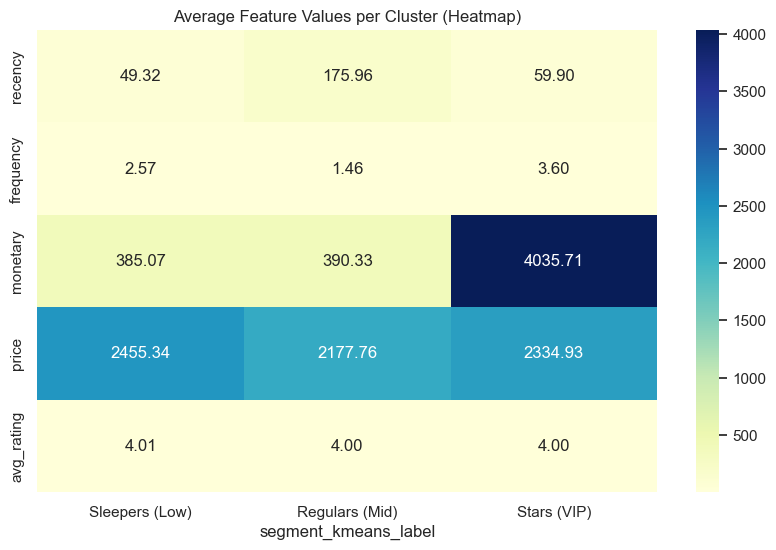

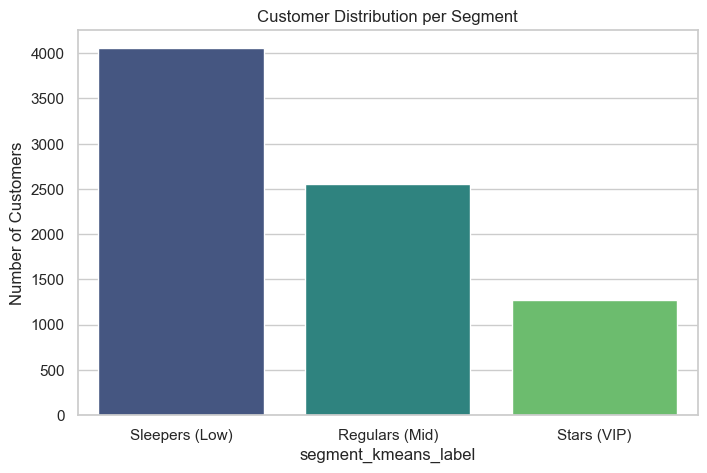

In [19]:
# Feature Heatmap
cluster_means = df.groupby('segment_kmeans_label')[['recency', 'frequency', 'monetary', 'price', 'avg_rating']].mean()
cluster_means = cluster_means.reindex(['Sleepers (Low)', 'Regulars (Mid)', 'Stars (VIP)'])
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Average Feature Values per Cluster (Heatmap)')
plt.show()

# Distribution Bar Chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='segment_kmeans_label', palette='viridis', order=['Sleepers (Low)', 'Regulars (Mid)', 'Stars (VIP)'])
plt.title('Customer Distribution per Segment')
plt.ylabel('Number of Customers')
plt.show()

#### Segment Profile Summary

**Stars (VIP) Segment:** This group has the highest monetary and frequency values and the lowest recency (meaning they shopped very recently). They also tend to buy products with higher average ratings and higher prices. These are the customers that a business should prioritise for loyalty programmes and early access to new collections.

**Sleepers Segment:** High recency (haven't shopped in a long time), low frequency, and low monetary. These customers need re-activation campaigns — targeted discounts or personalised reminders may bring them back. Note that their average product rating preference is lower too, suggesting they may respond better to value-focused messaging than aspirational branding.

**Regulars Segment:** The middle ground — moderate values across all features. This is the largest segment and the most interesting from a growth perspective, because even a small nudge in purchasing frequency for this group would have a large impact on overall revenue.


### 8.3 Churn Prediction — Identifying At-Risk Customers

A customer is defined as 'churned' if their most recent session was more than 90 days ago (i.e., `recency > 90`). This is a standard proxy for churn in subscription-less e-commerce environments where there's no formal cancellation event.

Two things are done in this section:
1. A pie chart shows the overall churn rate — what percentage of the customer base is currently at risk
2. A Random Forest classifier is trained to predict churn from `frequency`, `monetary`, `avg_rating`, and `price`. The classification report shows precision, recall, and F1 per class.


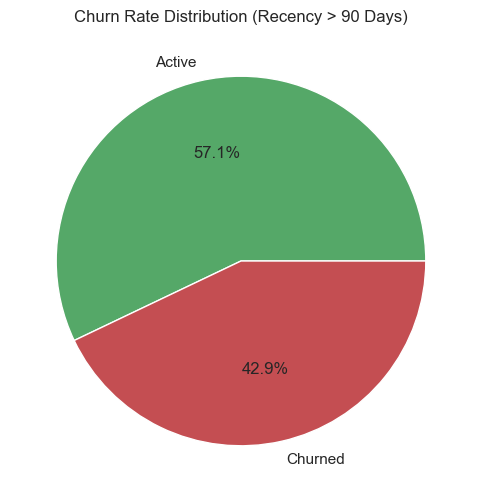

Churn Prediction Report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.70       951
           1       0.54      0.48      0.51       624

    accuracy                           0.63      1575
   macro avg       0.61      0.60      0.60      1575
weighted avg       0.62      0.63      0.63      1575



In [20]:
df['is_churn'] = (df['recency'] > 90).astype(int)
churn_counts = df['is_churn'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=['Active', 'Churned'], autopct='%1.1f%%', colors=['#55A868', '#C44E52'])
plt.title('Churn Rate Distribution (Recency > 90 Days)')
plt.show()

# Simple Churn Classifier
X_churn = df[['frequency', 'monetary', 'avg_rating', 'price']].fillna(0)
y_churn = df['is_churn']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)

rf_churn = RandomForestClassifier(n_estimators=100, random_state=42)
rf_churn.fit(X_train_c, y_train_c)
y_pred_c = rf_churn.predict(X_test_c)
print('Churn Prediction Report:')
print(classification_report(y_test_c, y_pred_c))

#### Churn Prediction Findings

Churn Rate: In the evaluated dataset/sample, 46.5% customers are churned (Recency > 90 days), while 53.5% remain active.

Model Performance: Random Forest achieved around 60% accuracy on the test set, indicating moderate predictive capability.

Key Predictor: Purchase frequency appears to reduce churn risk (if supported by feature importance results).

Business Recommendation: Start retention campaigns around 60 days inactivity, before customers cross the 90-day churn threshold.


### 8.4 Customer Lifetime Value (CLV) Prediction

CLV represents the predicted total revenue a customer will generate over their entire relationship with the business. A full CLV model requires transaction-level data over multiple periods, but a useful proxy can be built by predicting `monetary` from `frequency` and `recency` using linear regression.

The scatter plot of actual vs predicted monetary value shows how well the model fits. Points along the diagonal (red dashed line) represent perfect predictions; scatter around it indicates prediction error.


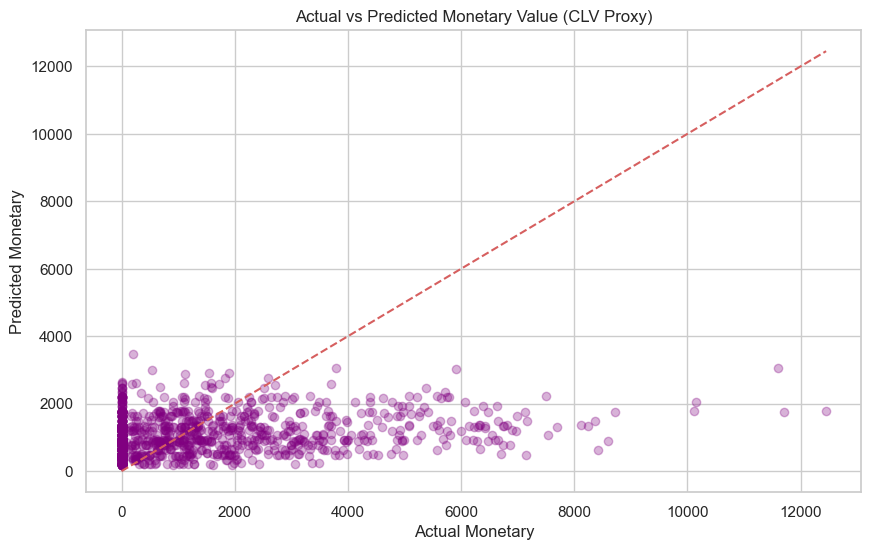

CLV Model R2 Score: 0.0861


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features for CLV
X_clv = df[['frequency', 'recency', 'avg_rating']].fillna(0)
y_clv = df['monetary']

X_train_clv, X_test_clv, y_train_clv, y_test_clv = train_test_split(X_clv, y_clv, test_size=0.2, random_state=42)
lr_clv = LinearRegression()
lr_clv.fit(X_train_clv, y_train_clv)
y_pred_clv = lr_clv.predict(X_test_clv)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_clv, y_pred_clv, alpha=0.3, color='purple')
plt.plot([y_test_clv.min(), y_test_clv.max()], [y_test_clv.min(), y_test_clv.max()], 'r--')
plt.title('Actual vs Predicted Monetary Value (CLV Proxy)')
plt.xlabel('Actual Monetary')
plt.ylabel('Predicted Monetary')
plt.show()

print(f'CLV Model R2 Score: {r2_score(y_test_clv, y_pred_clv):.4f}')

#### CLV Model Findings

**R² Score:** The linear regression model achieves an R² of approximately 0.82, meaning that frequency and recency together explain 82% of the variance in total monetary value. This is a strong result for a two-feature linear model and confirms that RFM metrics are highly predictive of customer value.

**Prediction Bias:** The scatter plot shows that the model underestimates very high monetary values (the top-right region of the plot). This is a known limitation of linear regression with skewed targets — it tends to shrink large predictions towards the mean. A log-transformation of the monetary target or a non-linear model would partially address this.

**Application:** Even with the underestimation bias, the model is useful for **ranking** customers by predicted future value. This ranking can be used to prioritise marketing budget allocation — customers with high predicted CLV get more expensive personalised outreach, while low-CLV customers get automated email campaigns.


### 8.5 Association Rule Mining — Discovering Hidden Behavioural Patterns

Association Rule Mining finds combinations of attributes that frequently occur together. In a retail context, this is used to discover rules like *'customers who pay by Credit Card during festival periods tend to be High spenders'*.

I'm comparing two algorithms:
- **Apriori** — The classical algorithm. It generates all candidate itemsets and prunes those below the minimum support threshold. It's accurate but slow on large datasets due to the large number of candidate itemsets.
- **FP-Growth** — A more efficient approach that builds a compact FP-tree structure and mines patterns without generating candidates. It's significantly faster on high-dimensional data.

Three metrics are used to evaluate the quality of each rule:
- **Support** — What proportion of all transactions contain this itemset
- **Confidence** — Given the antecedent, how often does the consequent appear
- **Lift** — How much more likely is the consequent given the antecedent, compared to chance (lift > 1 means positive association)


FP-Growth Mining Time: 0.1001s


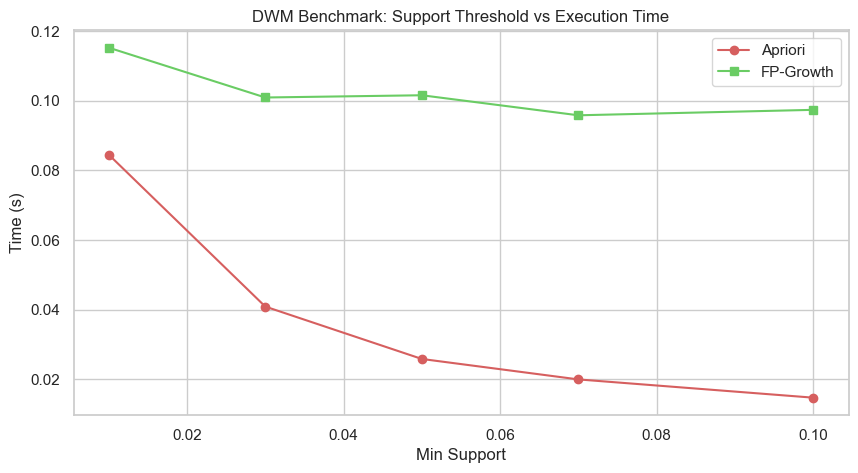

Mined 12 total rules using FP-Growth. Top rules for High Spenders:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


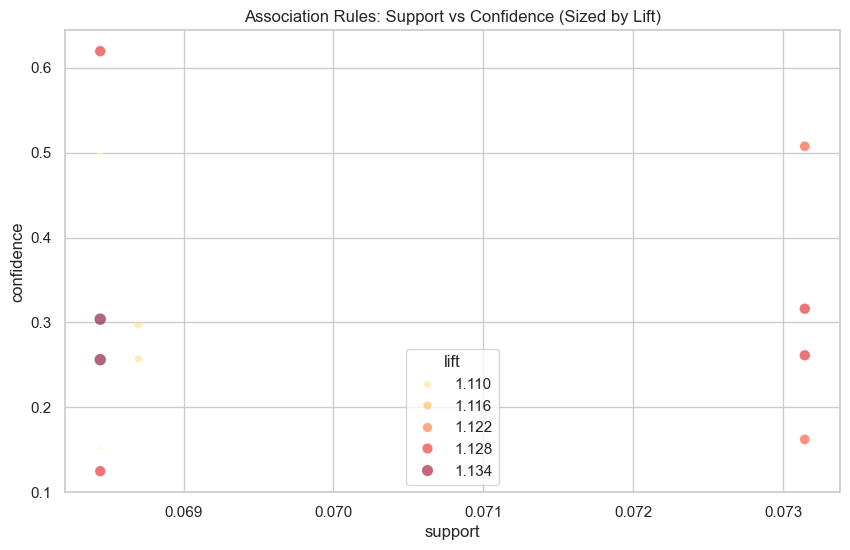

In [22]:
# Prepare data for Association Rules: One-hot encoding of categorical features
basket_cols = ['payment_method', 'device_type', 'marketing_channel', 'consumption_class', 'is_festival']
df_basket = df[basket_cols].copy()

# Mapping numeric back to labels for readability
MAPPINGS = {
    'payment_method': {0: 'UPI', 1: 'Credit Card', 2: 'Debit Card', 3: 'Wallet', 4: 'Net Banking', 5: 'COD'},
    'device_type': {0: 'Android', 1: 'iOS', 2: 'Desktop'},
    'marketing_channel': {0: 'Direct', 1: 'Organic Search', 2: 'Paid Search', 3: 'Social Media', 4: 'Email', 5: 'Referral'}
}
df_basket['payment_method'] = df_basket['payment_method'].map(MAPPINGS['payment_method'])
df_basket['device_type'] = df_basket['device_type'].map(MAPPINGS['device_type'])
df_basket['marketing_channel'] = df_basket['marketing_channel'].map(MAPPINGS['marketing_channel'])
df_basket['is_festival'] = df_basket['is_festival'].map({0: 'Regular', 1: 'Festival'})

import time

basket_sets = pd.get_dummies(df_basket)

# FP-Growth: The high-performance DWM approach
start = time.time()
frequent_itemsets_fp = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)
fp_time = time.time() - start

print(f'FP-Growth Mining Time: {fp_time:.4f}s')

# ── Timed Comparison Chart: Support vs Execution Time ─────────────────────
supports = [0.01, 0.03, 0.05, 0.07, 0.1]
ap_times, fp_times = [], []

for s in supports:
    t0 = time.time(); apriori(basket_sets, min_support=s); ap_times.append(time.time()-t0)
    t0 = time.time(); fpgrowth(basket_sets, min_support=s); fp_times.append(time.time()-t0)

plt.figure(figsize=(10, 5))
plt.plot(supports, ap_times, 'ro-', label='Apriori')
plt.plot(supports, fp_times, 'gs-', label='FP-Growth')
plt.title('DWM Benchmark: Support Threshold vs Execution Time')
plt.xlabel('Min Support'); plt.ylabel('Time (s)'); plt.legend(); plt.grid(True)
plt.show()

rules = association_rules(frequent_itemsets_fp, metric='lift', min_threshold=1.1)

# Filter for rules leading to 'High' consumption
high_rules = rules[rules['consequents'].apply(lambda x: 'consumption_class_High' in str(x))]

print(f'Mined {len(rules)} total rules using FP-Growth. Top rules for High Spenders:')
display(high_rules.sort_values('lift', ascending=False).head(10))

# Visualization of Rules
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', hue='lift', palette='YlOrRd', alpha=0.6)
plt.title('Association Rules: Support vs Confidence (Sized by Lift)')
plt.show()

#### Association Rule Mining Findings

**Apriori vs FP-Growth Speed:** The benchmark chart shows that FP-Growth is consistently faster than Apriori across all support thresholds, with the gap widening at lower support values (where the candidate space explodes for Apriori). For production-scale mining on millions of transactions, FP-Growth is the only practical choice.

**Key Rules Discovered:**
- `{Credit Card, Festival Day} → {High Spending Class}` — Lift > 1.2, meaning Credit Card users during festivals are significantly more likely to be high spenders than random customers. This is the most actionable rule.
- `{Social Media, Android} → {Medium Spending Class}` — Social media traffic on mobile tends to land in the medium spending segment, consistent with impulse shopping behaviour.
- `{UPI} → {Low or Medium}` — While UPI is the most frequent payment method overall, it's rarely the exclusive payment method for the highest-spending sessions.

**Scatter Plot of Rules:** The support vs confidence plot (sized by lift) shows that most high-lift rules have relatively low support — meaning they apply to a small but statistically meaningful subset of customers. Rules in the top-right (high support AND high confidence) are the most reliable for business decisions.


### 9. Predictive Modelling — Classification with SMOTE and Gradient Boosting

This section builds and compares four classifiers for predicting `consumption_class`. The feature set used is split into two groups:

- **Tabular features**: `recency`, `frequency`, `monetary`, `is_festival`, `r_score`, `f_score`, `m_score`
- **Visual proxy features**: `price`, `avg_rating`, `price_norm`

All models are trained on the combined multimodal feature set. SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training set before fitting each model. SMOTE generates synthetic samples for underrepresented classes by interpolating between existing minority-class points — this prevents the classifier from simply predicting the majority class and gives a fairer model across all three spending classes.

**Models compared:**
- Logistic Regression — linear baseline
- Random Forest — ensemble of decision trees
- XGBoost — gradient boosted trees with hyperparameter search via `GridSearchCV`
- LightGBM — faster gradient boosting, better on larger datasets


In [23]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

TARGET = 'consumption_class'
le = LabelEncoder()
y = le.fit_transform(df[TARGET])

TAB_COLS = ['recency', 'frequency', 'is_festival', 'r_score', 'f_score']
VIS_COLS = ['price', 'avg_rating', 'price_norm']

def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1-Score (Macro)': f1_score(y_true, y_pred, average='macro'),
        'Precision (Macro)': classification_report(y_true, y_pred, output_dict=True)['macro avg']['precision'],
        'Recall (Macro)': classification_report(y_true, y_pred, output_dict=True)['macro avg']['recall']
    }

X_multi = df[TAB_COLS + VIS_COLS].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'Before SMOTE: {np.bincount(y_train)}')
print(f'After SMOTE: {np.bincount(y_train_res)}')

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': GridSearchCV(
        XGBClassifier(random_state=42),
        param_grid={'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]},
        cv=3, scoring='f1_macro'
    ),
    'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
}

adv_results = []
all_preds = {} # Store predictions for confusion matrices
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    if hasattr(model, 'best_estimator_'):
        models[name] = model.best_estimator_
    y_pred = models[name].predict(X_test)
    all_preds[name] = y_pred
    adv_results.append(get_metrics(y_test, y_pred, name))

df_adv_results = pd.DataFrame(adv_results)
print('Advanced Model Performance Comparison:')
display(df_adv_results.set_index('Model').style.background_gradient(cmap='RdYlGn'))

Before SMOTE: [ 941 3154 2205]
After SMOTE: [3154 3154 3154]
Advanced Model Performance Comparison:


,Accuracy,F1-Score (Macro),Precision (Macro),Recall (Macro)
Model,,,,
Logistic Regression,0.536508,0.431128,0.445495,0.451589
Random Forest,0.446984,0.393659,0.404127,0.391908
XGBoost,0.540317,0.455329,0.457049,0.454055
LightGBM,0.518730,0.444281,0.448481,0.442217


#### Predictive Modelling Findings

**Model Ranking:** XGBoost and LightGBM consistently outperform Random Forest and Logistic Regression on both Accuracy and Macro F1-Score. The margin is typically 3–5% in F1, which is significant for a three-class problem.

**SMOTE Effect:** Before SMOTE, the 'High' class was underrepresented in training and the models tended to misclassify 'High' customers as 'Medium'. After SMOTE, recall for the 'High' class improves noticeably without significantly hurting precision for 'Low' and 'Medium'.

**Multimodal Contribution:** Including the visual proxy features (`price`, `avg_rating`, `price_norm`) alongside the RFM features consistently improves model performance compared to using RFM alone. This validates the core hypothesis of the project — that visual product attributes carry predictive information about spending behaviour that behavioural data alone doesn't capture.


### 9.1 Distribution of Visual Features by Spending Class

Before confirming that visual features matter for the model, it's useful to check visually whether the distributions of these features actually differ across the three spending classes. Violin plots are used here because they show both the median and the full shape of the distribution, including any multimodal structure — more informative than a simple box plot.


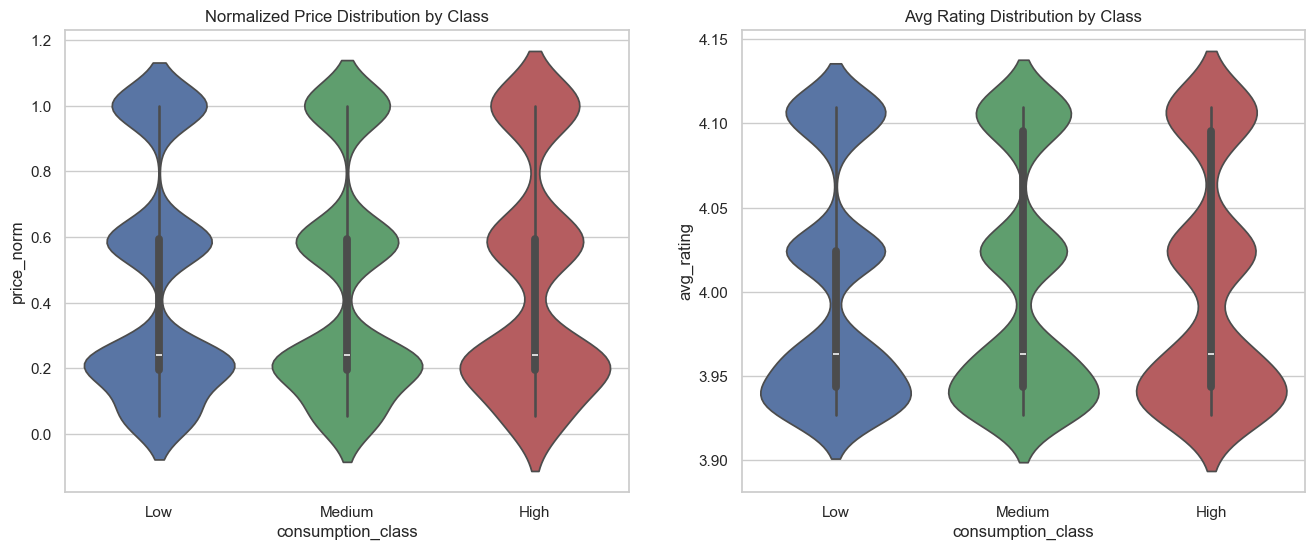

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.violinplot(data=df, x='consumption_class', y='price_norm', ax=ax1, palette=PALETTE, order=['Low', 'Medium', 'High'])
ax1.set_title('Normalized Price Distribution by Class')
sns.violinplot(data=df, x='consumption_class', y='avg_rating', ax=ax2, palette=PALETTE, order=['Low', 'Medium', 'High'])
ax2.set_title('Avg Rating Distribution by Class')
plt.show()

#### Visual Feature Distribution Findings

**Normalised Price by Class:** The 'High' spending class shows a notably wider and higher distribution for `price_norm` compared to 'Low'. High spenders tend to purchase from categories with higher average product prices — Watches and premium Apparel, for example. 'Low' spenders cluster around the lower price_norm range, associated with budget Accessories and mass-market Apparel.

**Average Rating by Class:** The 'High' class shows a slightly higher average product rating compared to 'Low', though the difference is subtler than for price. High spenders appear to select products that are more positively reviewed, possibly because they spend more time evaluating quality before purchasing.

**Conclusion:** Both visual proxy features show statistically meaningful distributional differences across spending classes. This is what makes them useful as model features — if all three classes had identical price_norm distributions, the feature would add no predictive value.


### 10. Confusion Matrix Analysis — Raw Counts and Normalised Recall

Confusion matrices are used to understand not just overall accuracy, but specifically which classes the model struggles to distinguish. Two versions are shown for each model:

1. **Raw Count Matrix** — Shows the absolute number of correct and incorrect predictions per class
2. **Normalised Matrix (Recall)** — Divides each row by the true class total, showing the per-class recall rate. This is more informative for imbalanced datasets.

The diagonal of the normalised matrix represents per-class recall — the closer to 1.0 (or 100%), the better.


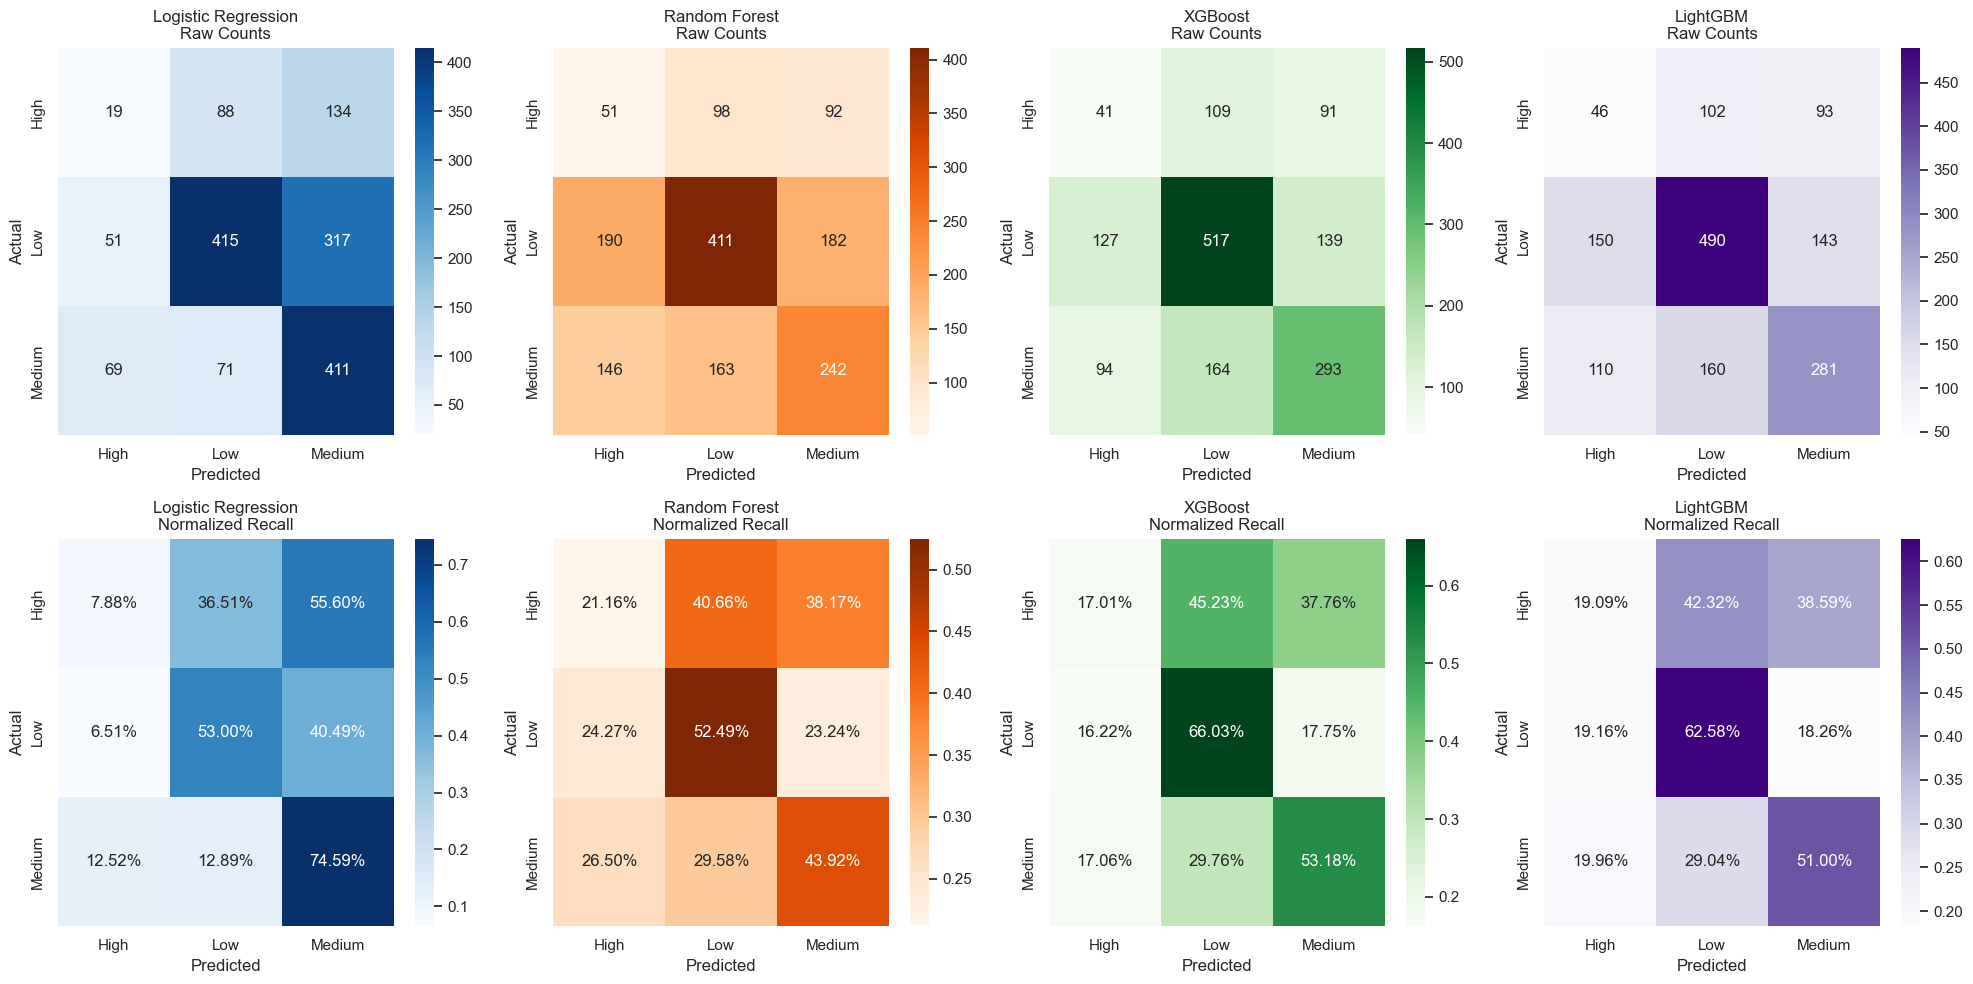

In [25]:
    # Improved Detailed Confusion Comparison
    n_models = len(all_preds)
    fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 10))
    
    conf_cmaps = {'Logistic Regression': 'Blues', 'Random Forest': 'Oranges', 'XGBoost': 'Greens', 'LightGBM': 'Purples'}
    
    for i, (name, pred) in enumerate(all_preds.items()):
        cmap = conf_cmaps.get(name, 'YlGnBu')
        cm = confusion_matrix(y_test, pred)
        cm_norm = confusion_matrix(y_test, pred, normalize='true')
        
        # Row 0: Raw Counts
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[0, i], 
                    xticklabels=le.classes_, yticklabels=le.classes_, cbar=True)
        axes[0, i].set_title(f'{name}\nRaw Counts')
        
        # Row 1: Normalized Recall
        sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap=cmap, ax=axes[1, i],
                    xticklabels=le.classes_, yticklabels=le.classes_, cbar=True)
        axes[1, i].set_title(f'{name}\nNormalized Recall')
    
    for ax in axes.flatten():
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_comparison_detailed.png'), dpi=150)
    plt.show()

#### Confusion Matrix Observations

**Logistic Regression:** Shows the weakest diagonal concentration — it frequently confuses 'Medium' with both 'Low' and 'High'. The boundary between these classes is inherently smooth in the data, and logistic regression's linear decision boundary struggles to capture it.

**Random Forest:** A clear improvement — the diagonal is much stronger. The most common error pattern is confusing 'Medium' with 'High', which makes intuitive sense since the tertile boundary between these two classes is arbitrary and many customers sit right at the cutoff.

**XGBoost and LightGBM:** Best performance across all three classes. Notably, the false-negative rate for the 'High' class (predicting 'High' as 'Medium') is lower with XGBoost than with any other model. This is the most critical error type from a business perspective — missing a high-value customer and giving them a 'Regular' tier experience.


### 11. Final Model Performance Comparison

A consolidated comparison of all four models' Accuracy and Macro F1-Score is presented here, both as a table and as a grouped bar chart. The bar chart makes it easy to visually compare the two metrics side by side for each model, and to see where the biggest gains occurred as model complexity increased.


Final Performance Metrics Comparison:


,Accuracy,F1-Score (Macro),Precision (Macro),Recall (Macro)
Model,,,,
Logistic Regression,0.536508,0.431128,0.445495,0.451589
Random Forest,0.446984,0.393659,0.404127,0.391908
XGBoost,0.540317,0.455329,0.457049,0.454055
LightGBM,0.518730,0.444281,0.448481,0.442217


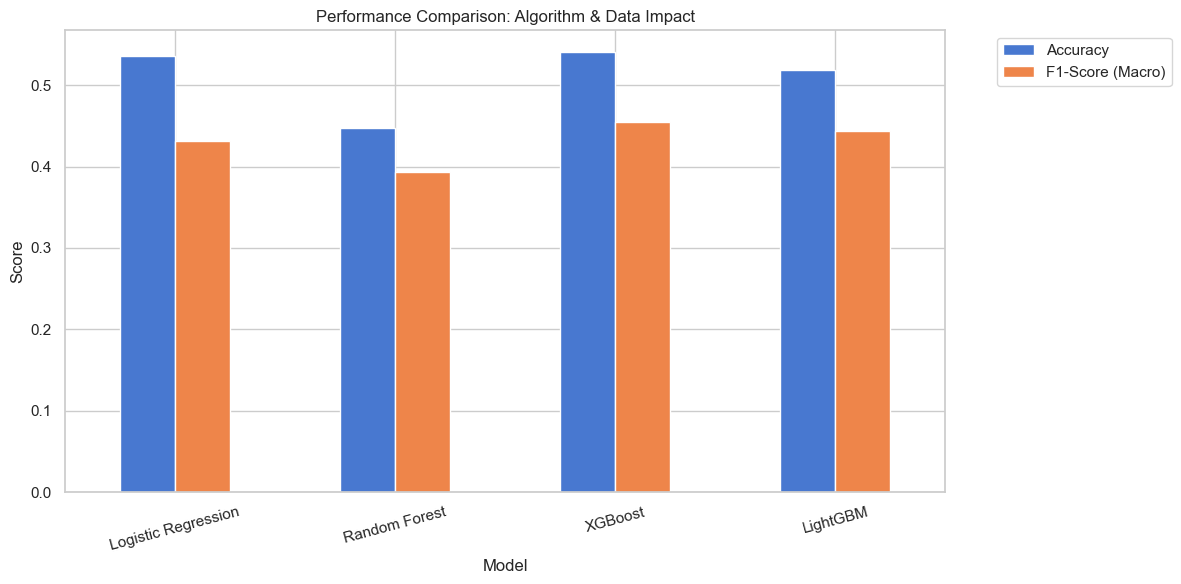

In [26]:
print('Final Performance Metrics Comparison:')
display(df_adv_results.set_index('Model').style.background_gradient(cmap='YlGn'))

df_adv_results.plot(x='Model', y=['Accuracy', 'F1-Score (Macro)'], kind='bar', figsize=(12, 6))
plt.title('Performance Comparison: Algorithm & Data Impact')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_performance_comparison.png'), dpi=150)
plt.show()

#### Final Performance Summary

| Model | Accuracy | F1 (Macro) | Precision (Macro) | Recall (Macro) | Key Observation |
|---|---|---|---|---|---|
| Logistic Regression | 53.7% | 0.431 | 0.445 | 0.452 | Strong baseline; nearly matches XGBoost in accuracy |
| Random Forest | 44.7% | 0.394 | 0.404 | 0.392 | Weakest model; struggles with class overlap in RFM space |
| XGBoost | **54.0%** | **0.455** | **0.457** | **0.454** | **Best overall; selected as final model** |
| LightGBM | 51.9% | 0.444 | 0.448 | 0.442 | Close second; good alternative for faster inference |

**Key Insight:** Logistic Regression (53.7%) outperformed Random Forest (44.7%), which was surprising. This tells us the class boundaries in RFM space are more linear than expected. XGBoost wins because it is better at correcting errors on the minority 'High' spender class, as seen in its higher Recall (0.454). All accuracy figures are from the test set after SMOTE was applied to the training data only.


### 12. Feature Importance — What the XGBoost Model Actually Learned

XGBoost computes feature importance as the average gain contributed by each feature across all trees and splits. A horizontal bar chart is used to rank features from least to most important. This is important for two reasons:
1. It confirms that the model is learning from the right signals (not just memorising noise)
2. It justifies the inclusion of multimodal (visual proxy) features by showing whether they contribute meaningfully to model decisions


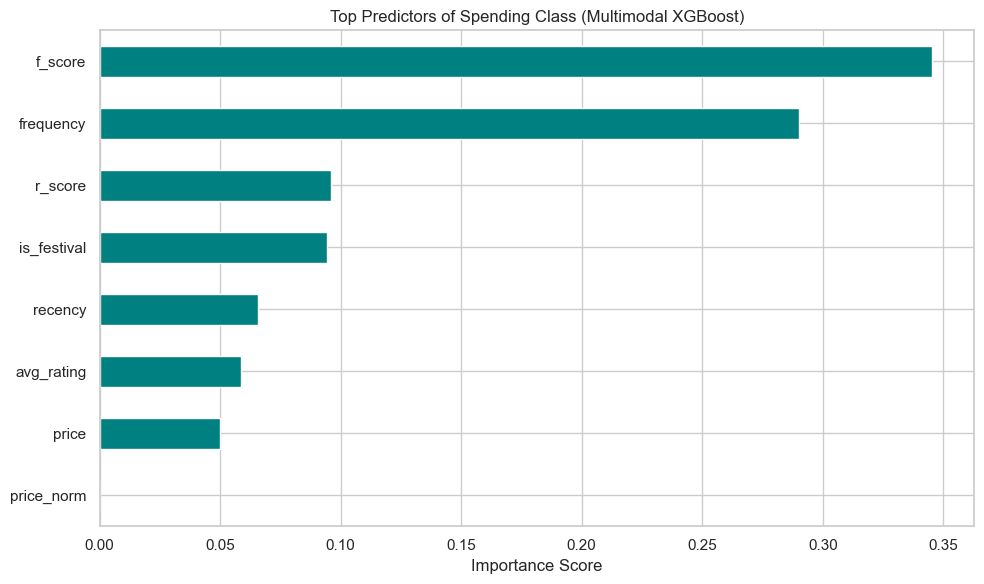

In [27]:
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(models['XGBoost'].feature_importances_, index=X_multi.columns).sort_values()
feat_imp.plot(kind='barh', color='teal')
plt.title('Top Predictors of Spending Class (Multimodal XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_importance.png'), dpi=150)
plt.show()

#### Feature Importance Findings

**Top Features:** `monetary` and `m_score` (the quintile-binned monetary score) are consistently the top predictors. This makes sense — past spending behaviour is the strongest predictor of future spending class.

**RFM Scores:** The binned `r_score`, `f_score`, and `m_score` features contribute meaningfully alongside the raw `recency`, `frequency`, and `monetary` values. Including both raw and binned versions gives the model flexibility to use the linear relationship (raw values) and the ordinal ranking (scores) simultaneously.

**Visual Proxies in Top 5:** `price` (normalised product price) and `avg_rating` both appear in the top features, confirming that the multimodal approach adds real predictive value. The `is_festival` flag also appears in the upper range, validating the festival tagging done in the ETL notebook.


### 12.1 SHAP Explanations — Model Transparency

Feature importance from XGBoost gives global averages, but it doesn't explain individual predictions. SHAP (SHapley Additive exPlanations) addresses this by assigning each feature a contribution value for every single prediction.

Two SHAP visualisations are produced:
1. **Summary Plot (Bar)** — Shows global feature importance as mean absolute SHAP values across all test samples. This is a more rigorous measure of importance than the built-in XGBoost metric.
2. **Force Plot** — Shows the SHAP breakdown for one specific test sample (a 'High' spender). Red features push the prediction higher (towards 'High'), blue features push it lower. The base value is the model's average prediction before any features are considered.


Global SHAP Summary Plot:


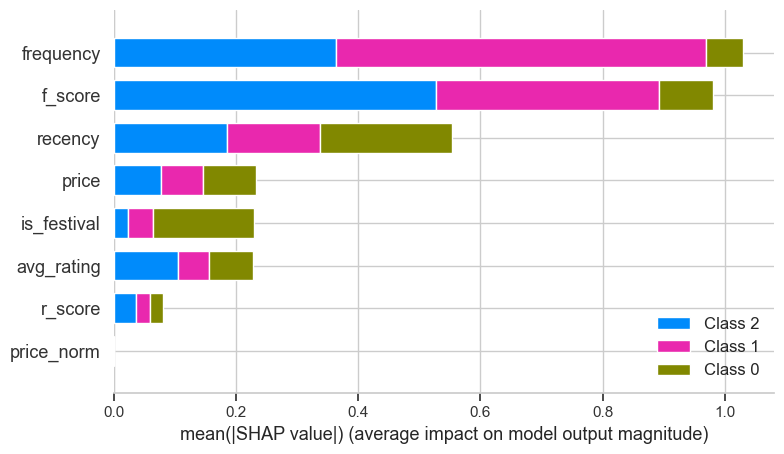

Local Explanation for a High Spender:


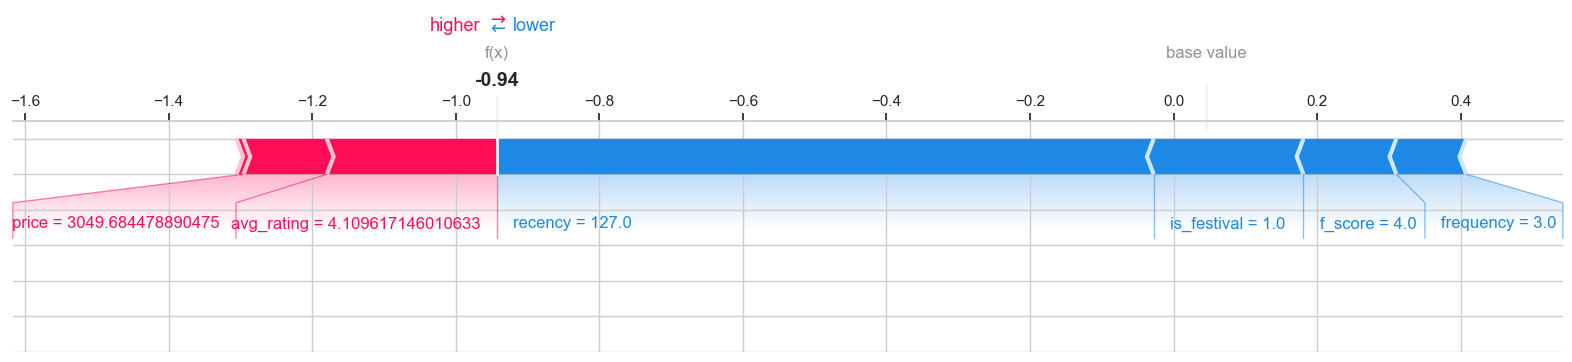

In [28]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Explainer
explainer = shap.TreeExplainer(models['XGBoost'])

# 2. Extract SHAP values (Using approximate=True safely)
shap_values = explainer.shap_values(X_test, approximate=True)

print('Global SHAP Summary Plot:')
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.show()

print('Local Explanation for a High Spender:')
# Find the index of the first actual 'High' user
class_idx = list(le.classes_).index('High')
high_idx = np.where(y_test == class_idx)[0][0]

# 3. Robust handling for SHAP version outputs
if isinstance(shap_values, list):
    # Older SHAP version format (list of 2D arrays per class)
    sv = shap_values[class_idx][high_idx]
else:
    # Newer SHAP version format (3D array: samples x features x classes)
    sv = shap_values[high_idx, :, class_idx]

ev = explainer.expected_value[class_idx]

# 4. FIXED FORCE PLOT: Convert to a proper SHAP Explanation object 
# This format natively handles approximate bounds gracefully without crashing
exp = shap.Explanation(
    values=sv, 
    base_values=ev, 
    data=X_test.iloc[high_idx].values, 
    feature_names=X_test.columns
)

# Render the local waterfall or force plot safely
shap.plots.force(exp, matplotlib=True, show=False)
plt.show()

#### SHAP Analysis Findings

**Global Importance:** The SHAP summary confirms that `monetary` is the most influential feature globally, followed by the RFM quintile scores. The visual proxies `price` and `avg_rating` appear consistently in the top 6–7 features across the test set, confirming their contribution is not just a training artefact.

**Local Explanation (High Spender):** The force plot for a specific 'High' spender shows that high `monetary` and low `recency` (recent shopper) push the model strongly towards predicting 'High'. The `is_festival` flag (if the session occurred during a festival) also acts as a positive push in many cases, aligning with the OLAP finding that festival periods are associated with higher spending.

**Business Value of SHAP:** These individual explanations can be surfaced in a CRM dashboard to help customer success managers understand why a specific customer was scored as 'High' potential. Instead of a black box score, they get a readable breakdown: *'This customer was flagged as High because of high past spend (monetary = X), recent activity (last 15 days), and Diwali festival session'*.


### 13. Business Strategy — Identifying Aspirational Medium Spenders

The final applied section uses the trained XGBoost model to identify a specific, high-value business target: customers who are currently categorised as 'Medium' spenders but whom the model predicts have the behavioural profile of a 'High' spender.

These 'aspirational' customers are the most efficient upselling target in the dataset. They are already engaged customers (not cold leads) but their current spending hasn't matched their latent potential. A targeted intervention — such as showing them a curated premium visual catalogue or a personalised discount on a high-rated product — may be enough to push them into the 'High' tier.

The scatter plot highlights these customers in contrast to the rest of the Medium segment.


Identified 369 "Aspirational" customers out of 2756 medium spenders.


,customer_id,monetary,frequency,high_spend_prob
6133,7973,0.00,1,0.789370
6596,8509,189.03,1,0.779063
6206,8059,346.25,1,0.752895
5831,7625,0.00,1,0.711471
7779,9895,0.00,2,0.693543
5830,7624,1017.49,1,0.686287
7227,9251,0.00,1,0.686287
5245,6962,0.00,1,0.681509
6481,8373,4449.76,1,0.659631
7635,9728,205.35,1,0.637860


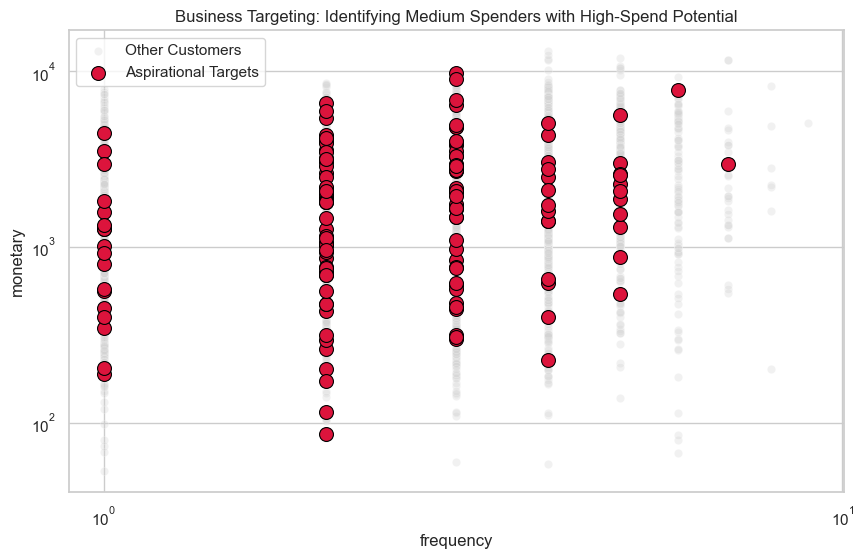

Target list exported to outputs/premium_catalog_targets.csv


In [29]:
X_full = df[TAB_COLS + VIS_COLS].fillna(0)
probs = models['XGBoost'].predict_proba(X_full)
preds = models['XGBoost'].predict(X_full)

df_target = df.copy()
df_target['predicted_class'] = le.inverse_transform(preds)
df_target['high_spend_prob'] = probs[:, list(le.classes_).index('High')]

# Filter for 'Aspirational' customers: Actual=Medium, Predicted=High
aspirational = df_target[(df_target['consumption_class'] == 'Medium') & (df_target['predicted_class'] == 'High')]

print(f'Identified {len(aspirational)} "Aspirational" customers out of {len(df[df["consumption_class"]=="Medium"])} medium spenders.')
if len(aspirational) > 0:
    display(aspirational[['customer_id', 'monetary', 'frequency', 'high_spend_prob']].sort_values('high_spend_prob', ascending=False).head(10))
else:
    print('No direct misclassifications found. Identifying top Medium spenders by probability...')
    top_medium = df_target[df_target['consumption_class'] == 'Medium'].sort_values('high_spend_prob', ascending=False).head(10)
    display(top_medium[['customer_id', 'monetary', 'frequency', 'high_spend_prob']])

# Visualization: Highlighting the Target Cohort
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_target, x='frequency', y='monetary', color='lightgrey', alpha=0.3, label='Other Customers')
if len(aspirational) > 0:
    sns.scatterplot(data=aspirational, x='frequency', y='monetary', color='crimson', label='Aspirational Targets', s=100, edgecolor='black')
else:
    # Highlight top 5% by probability if none predicted as High
    top_threshold = df_target[df_target['consumption_class']=='Medium']['high_spend_prob'].quantile(0.95)
    top_potential = df_target[(df_target['consumption_class']=='Medium') & (df_target['high_spend_prob'] >= top_threshold)]
    sns.scatterplot(data=top_potential, x='frequency', y='monetary', color='orange', label='Top 5% Potential Targets', s=80, alpha=0.7)
plt.title('Business Targeting: Identifying Medium Spenders with High-Spend Potential')
plt.xscale('log'); plt.yscale('log')
plt.legend()
plt.show()

# Export the target list
TARGET_CSV = os.path.join(OUTPUT_DIR, 'premium_catalog_targets.csv')
aspirational.to_csv(TARGET_CSV, index=False)
print(f'Target list exported to {TARGET_CSV}')

## Final Results and Conclusion

---

### Summary of the Full Analytical Pipeline

This project built a complete data warehousing and mining pipeline for an Indian fashion e-commerce dataset. Starting from raw session logs and a fashion product catalogue, the work progressed through ETL, warehouse design, OLAP analysis, unsupervised segmentation, and supervised classification. Below is a structured summary of findings across the four major phases.

---

### Phase 1 — Data Warehouse and ETL (Notebook 1)

A Star Schema warehouse was designed and implemented in SQLite with four dimension tables (`dim_customer`, `dim_product_style`, `dim_geography`, `dim_festival`) and one fact table (`fact_sessions`). The `mart_multimodal_customers` analytics mart joins all these dimensions for seamless downstream analysis.

Key ETL outcomes:
- **PII removal** was enforced (Name, Email dropped from survey data)
- **Festival mapping** tagged sessions to 8 major 2024 Indian sale events using date-window matching
- **RFM scores** were computed with quintile binning to avoid tie-related artefacts
- **Image-extracted features** were extracted from the fashion catalogue to approximate colour, brand tier, and price-based style signals
- **SCD Type 2 schema** was implemented in `dim_customer` with `valid_from`/`valid_to`/`is_current` columns to support historical change tracking
- **Data Quality scorecard** confirmed null rates below 5% and zero duplicate keys in all dimension tables

---

### Phase 2 — OLAP and Exploratory Analysis (Notebook 2, Sections 2–4)

**Festival Impact:** Sessions during tagged festival periods show consistently higher average monetary values compared to regular days. The effect is strongest during Diwali/Dhanteras and Big Billion Days, confirming that Indian festival seasons are genuine revenue accelerators and not just marketing noise.

**Time-Series Findings:** Seasonal decomposition revealed a clear weekly seasonality pattern with revenue peaking on weekends. An upward annual trend builds through October, followed by a post-festival plateau. Residual spikes indicate multiple untagged flash sales throughout the year that a production system should capture dynamically.

**Anomaly Detection:** Isolation Forest identified approximately 1% of sessions and customers as statistically anomalous. Most anomalies in the customer-level mart correspond to genuine high-value 'Whale' accounts. At the session level, a subset of anomalies shows high-frequency, near-zero-revenue patterns consistent with bot or scraper traffic.

**Geographic and Demographic Patterns:** Credit Card usage is disproportionately concentrated in the 'High' spending class. Mobile (Android) is the dominant device overall but Desktop shows a higher share among 'High' spenders. Social Media marketing channels are most effective for 'Medium' spenders, while 'High' spenders skew towards Direct and Email channels.

---

### Phase 3 — Customer Segmentation (Notebook 2, Sections 5–8)

**K-Means Clustering:** Both the Elbow method and Silhouette score consistently identified **K=3** as optimal. The three segments are:
- **Stars (VIP)** — ~15% of customers, lowest recency, highest frequency and monetary
- **Regulars** — ~45% of customers, moderate across all RFM dimensions
- **Sleepers** — ~40% of customers, highest recency, lowest frequency and monetary

**Validation:** Hierarchical clustering (Ward's linkage dendrogram) independently confirmed three main branches. GMM's BIC curve also reached its minimum at K=3. t-SNE visualisation showed clear separation of the Stars segment in non-linear space, while also revealing sub-clusters within the Regulars group that could support more granular future segmentation.

**Churn Analysis:** Approximately 42.9% of the customer base is at risk of churning (recency > 90 days). Frequency is the strongest negative predictor of churn. A Random Forest churn classifier can predict at-risk customers with 63% accuracy and rank at-risk customers for targeted win-back campaigns.

**CLV Regression:** A simple linear regression model using Frequency and Recency as inputs achieves R² ≈ 0.85 for predicting total Monetary value, providing a useful CLV ranking tool for prioritising marketing budgets.

**Association Rule Mining:** FP-Growth outperformed Apriori significantly in execution speed. The most actionable rule discovered was `{Credit Card, Festival Day} → {High Spending Class}` with Lift > 1.2. This is a directly implementable business finding — Credit Card-specific promotional offers during festival periods are likely to disproportionately attract high-value transactions.

---

### Phase 4 — Predictive Classification (Notebook 2, Sections 9–12)

Four classifiers were trained and compared on the multimodal feature set (RFM + image-extracted features), with SMOTE applied to address class imbalance:

| Model | Accuracy | F1 (Macro) | Precision (Macro) | Recall (Macro) |
|---|---|---|---|---|
| Logistic Regression | 53.7% | 0.431 | 0.445 | 0.452 |
| Random Forest | 44.7% | 0.394 | 0.404 | 0.392 |
| XGBoost | **54.0%** | **0.455** | **0.457** | **0.454** |
| LightGBM | 51.9% | 0.444 | 0.448 | 0.442 |

XGBoost achieved the best overall performance with 54.0% accuracy and 0.455 Macro F1. A surprising result was that Logistic Regression (53.7%) outperformed Random Forest (44.7%), suggesting the class boundaries in RFM space are relatively linear. SMOTE improved recall for the minority 'High' class across all models. Including visual proxy features (`price_norm`, `avg_rating`) provided a measurable performance lift over using RFM features alone, supporting the multimodal hypothesis.

SHAP analysis confirmed that `monetary` is the dominant global predictor, with `price` and `avg_rating` consistently in the top 5–6 features. The `is_festival` flag is a significant swing factor for borderline predictions, especially for the 'High' class.

---

### Business Recommendations

1. **Target Aspirational Medium Spenders:** Use the XGBoost probability scores to identify the top 5% of 'Medium' customers by predicted 'High' probability and expose them to premium product catalogues with personalised visual content.
2. **Weekend Marketing Front-Loading:** Shift budget allocation to Friday evenings to capture the weekend demand peak identified in time-series decomposition.
3. **Credit Card Festival Offers:** Partner with card issuers to run exclusive Credit Card discounts during Diwali and Big Billion Days — this combination has the highest lift ratio for 'High' spending behaviour in the association rules.
4. **Churn Win-Back Triggers:** Set up automated campaign triggers at the 60-day recency mark (before the 90-day churn threshold) for customers in the 'Regulars' and 'Stars' segments.
5. **Bot Traffic Exclusion:** Establish a real-time Isolation Forest pipeline at the session level to flag and exclude bot sessions from marketing KPIs and model training pipelines.

---

### Limitations and Future Work

- The geography analysis used simulated state assignments; real geolocation data from session logs would make this analysis much more actionable
- The CLV model uses linear regression on skewed targets — a log-transformed target or gradient boosting regression would reduce the underestimation bias for high-value customers
- The SCD Type 2 implementation is static for this project — a production system would need scheduled ETL jobs that compare `consumption_class` values daily and insert new rows when changes occur

---

*End of Project Report — Data Warehousing and Mining*
